<a href="https://colab.research.google.com/github/Y4G0SL/MVPDataScience/blob/main/MVP1_Analise_de_dados_e_Boas_praticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Yago Soares Laguna

**Matrícula:** 4052025001118

**Dataset:** [Gaming profiles 2025 (Steam)](https://www.kaggle.com/datasets/artyomkruglov/gaming-profiles-2025-steam-playstation-xbox)

# Descrição dos conjuntos de dados

O Dataset Gaming Profile fornece informações sobre os perfis dos jogadores (Usuários) e seus movimentos dentro das plataformas Playstation, Xbox, Steam.<br>
Para esta análise irei utilizar de dentro deste Dataset os dados que englobam a plataforma de jogos Steam através da análise dos seguintes arquivos:<br>
- **players.csv:** Conjunto de dados em que contém o id do usuário, seu país, e a data de criação de sua conta;<br>
- **history.csv:** Conjunto de dados em que contém o id do usuário, id da conquista que o jogador adquiriu, Data de aquisição;<br>
- **games.csv:** Conjunto de dados que contém o id dos jogos, O titulo do jogo, a desenvolvedora, a publicadora, o gênero do jogo; as linguagens suportadas e a data de lançamento;<br>
- **prices.csv:** Conjunto de dados que contém o id do jogo, seu valor em moedas variadas(Dólar EUA(USD), Euro(EUR), Libra esterlina(GBP), Iene Japonês(JPY), Rublo russo(RUB)) e a data em que foi capturado o preço para o conjunto;<br>
- **purchased_games.csv:** Conjunto de dados que contém o id do usuário e sua biblioteca com os ids dos jogos;<br>
- **achievements.csv:** Conjunto de dados que contém as conquistas dos jogos.<br><br>

todos estes conjuntos foram retirados do Dataset citado.   

# Descrição do problema

Através do Dataset Gaming Profile(Steam) buscaremos saber quais são os jogos mais populares e se sua produtora tem alguma influencia no mercado, assim como a relação entre o gênero do jogo e sua popularidade. Também se possível analisar o comportamento dos usuários em relação à aquisição e uso dos jogos adquiridos.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

- É possível que um usuário adquira jogos e não os jogue?

- Um usuário gasta muito dinheiro para construir sua biblioteca?

- Tem algum gênero de jogo que é preferência pelos usuários?

- Os jogos mais vendidos são de uma mesma desenvolvedora?

## Tipo de Problema não supervisionado
Pela natureza dos dados trabalhados não tendo rótulos e nem um tipo de indicador para onde ir, é necessário analisar o comportamento dos dados através de iterações e combinações de dados para se poder extrair informações que são uteis para entender melhor o que os dados nos informam. E isso é essencial para realizar aprendizado não supervisionado.

## Atributos dos conjuntos originais
O conjunto **games** contém 98248 linhas que representam as caracteristicas dos jogos. Contém 7 atributos:
- **gameid** (Identificador do jogo em formato numérico)
- **title** (Título do jogo)
- **Developers** (Lista com o nome de suas desenvolvedoras)
- **publishers** (Lista com o nome de suas publicadoras)
- **genres** (Lista com o nome dos generos em que o jogo se enquadra)
- **supported_languages** (Lista com as línguas que o jogo foi dublado ou legendado)
- **release_date** (Data de lançamento do jogo)<br>
<br>

O conjunto **achievements** contém 1939027 linhas que representam cada conquista que pode ser adquirida em jogos que contenham conquistas. Contém 4 atributos:
- **achievementid** (Identificador da conquista em relação ao jogo)
- **gameid** (Identificador do jogo em formato numérico)
- **Title** (Nome da conquista dentro do jogo)
- **description** (Descrição da conquista)<br>
<br>

O conjunto **prices** contém 4414273 linhas que representam os valores cobrados pelos jogos em 5 moedas diferentes. Contém 7 atributos:
- **gameid** (Identificador do jogo em formato numérico)
- **usd** (Moeda Dólar EUA)
- **eur** (Moeda Euro)
- **gbp** (Moeda Libra Esterlina)
- **jpy** (Moeda Iene Japonês)
- **rub** (Moeda Rublo Russo)
- **date_acquired** (Data de coleta da informação)<br>
<br>

O conjunto **players** contém 424683 linhas que representam dados da conta do usuário, desde que seja pública. Contém 3 atributos:
- **playerid** (Identificador do jogador)
- **country** (País do qual o usuário pertence)
- **created** (A data que foi criada a conta do usuário)<br>
<br>


O conjunto **history** contém 10693879 linhas que representam os registros das conquistas adquiridas pelo usuário. Contém 3 atributos:
- **playerid** (Identificador do jogador)
- **achievementid** (Id da conquista do jogo)
- **date_acquired** (A data que foi adquirida a conquista)<br>
<br>


O conjunto **purchased_games** contém 102548 linhas que representam os jogos comprados pelo jogador, ou, a sua biblioteca. Contém 2 atributos:
- **playerid** (Identificador do jogador)
- **library** (Lista com os ids dos jogos que o jogador possui)
<br>


# Importação das Bibliotecas Necessárias e Carga de Dados

A seguir serão importadas todas as bibliotecas necessárias para o pré-processamento de dados, a sua análise e a sua representação.

In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import missingno as ms
import seaborn as sns

In [3]:
# importando os databases

games = pd.read_csv('https://meus-csv-estudos.s3.us-east-2.amazonaws.com/games.csv')
achievements = pd.read_csv('https://meus-csv-estudos.s3.us-east-2.amazonaws.com/achievements.csv')
history = pd.read_csv('https://meus-csv-estudos.s3.us-east-2.amazonaws.com/history.csv')
players = pd.read_csv('https://meus-csv-estudos.s3.us-east-2.amazonaws.com/players.csv')
prices= pd.read_csv('https://meus-csv-estudos.s3.us-east-2.amazonaws.com/prices.csv')
purchased_games = pd.read_csv('https://meus-csv-estudos.s3.us-east-2.amazonaws.com/purchased_games.csv')

# Unificação dos conjuntos

Os conjuntos possuem muitos dados separados que poderiam estar em um só, por este motivo irei transformar os seis conjuntos em no máximo 2 conjuntos com os principais dados para a resolução dos problemas. Para assim após começar o tratamento real dos dados.

****

##Unificação para o conjunto **games**
Conjuntos **games, achievements, prices** podem ser unificados, pois ambos possuem o ID do jogo que será o guia para esta unificação.<br>
Utilizaremos games como conjunto central desta unificação.

In [4]:
# Realizando ajustes no conjunto games

games_atual = games.drop(columns=['release_date']) # Realizando a exclusão da coluna release_dates, pois ela não irá influenciar na resolução dos problemas definidos

games_atual

,gameid,title,developers,publishers,genres,supported_languages
0,3281560,Horror Game To Play With Friends! Playtest,NaN,NaN,NaN,NaN
1,3280930,Eternals' Path Playtest,NaN,NaN,NaN,NaN
2,3280770,ANGST: A TALE OF SURVIVAL - Singleplayer Playtest,NaN,NaN,NaN,NaN
3,3279790,Montabi Playtest,NaN,NaN,NaN,NaN
4,3278320,파이팅걸 유리 Playtest,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese']
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese']
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp..."
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English']


In [5]:
# Realizando ajustes no conjunto achievements

achievements_atual = achievements.drop(columns=['description'])  # A descrição das conquistas não será utilizada para realizar as análises.
                                                                 # Assim a coluna 'description' será excluída.

achievements_atual

,achievementid,gameid,title
0,2621440_ACH_FIRST_KILL,2621440,FIRST KILL
1,2621440_ACH_0_LEVEL_COMPLETED,2621440,TUTORIAL COMPLETED
2,2621440_ACH_1_LEVEL_COMPLETED,2621440,FIRST LEVEL
3,2621440_ACH_2_LEVEL_COMPLETED,2621440,SECOND LEVEL
4,2621440_ACH_3_LEVEL_COMPLETED,2621440,THIRD LEVEL
...,...,...,...
1939022,3399670_CHECKMATE,3399670,Checkmate!
1939023,3399670_SUNK,3399670,They have sunk into oblivion.
1939024,3399670_SHATTERED,3399670,Shattered!
1939025,3399670_SMILE,3399670,Smile!


O conjunto **prices** tem o um tamanho estranhamente grande, por este motivo os ajustes deste conjunto serão mais complexos.

In [6]:
# Exibindo o conjunto para verificação

prices

,gameid,usd,eur,gbp,jpy,rub,date_acquired
0,3281560,NaN,NaN,NaN,NaN,NaN,2024-11-28
1,3280930,NaN,NaN,NaN,NaN,NaN,2024-11-28
2,3280770,NaN,NaN,NaN,NaN,NaN,2024-11-28
3,3279790,NaN,NaN,NaN,NaN,NaN,2024-11-28
4,3278320,NaN,NaN,NaN,NaN,NaN,2024-11-28
...,...,...,...,...,...,...,...
4414268,1499520,NaN,NaN,NaN,NaN,NaN,2025-02-24
4414269,1499540,NaN,NaN,NaN,NaN,NaN,2025-02-24
4414270,1499550,2.24,1.79,1.79,234.0,59.0,2025-02-24
4414271,1498590,0.99,0.99,0.89,120.0,42.0,2025-02-24


Notei que o conjunto é extremamente grande em linhas, o que é estranho tendo em vista que a loja Steam tem aproximadamente 110 mil jogos em sua loja. Com isso verifiquei as datas na coluna "date_acquired" para ver se existia datas diferentes.

In [7]:
# Realizando a contagem de ocorrência de valores na coluna "date_acquired"

prices['date_acquired'].value_counts()
len(prices['date_acquired'].value_counts())

45

Através desta contagem notei que haviam em torno de 45 registros para cada gameid dentro do conjunto, o que deixou o conjunto muito grande.<br>
Com isso a melhor opção é escolher os dados mais atualizados para se ter os valores mais fidedignos com o presente. Porém é preciso saber se realmente todas as datas tem o mesmo valor, assim podendo escolher a data que é mais completa.

In [8]:
# Para isso irei ordenar os valores de acordo com a data, sendo a mais recente e com o maior valor no topo

prices['date_acquired'].sort_values(ascending=False).value_counts(sort=True, ascending=False)

,count
date_acquired,
2025-02-24,98465
2025-02-22,98465
2025-02-20,98465
2025-02-18,98465
2025-02-16,98465
2025-02-14,98465
2025-02-12,98465
2025-02-10,98465
2025-02-08,98465


Agora que eu sei que a data mais recente é a de 2025-02-24 e ela esta no topo da filtragem posso ajustar este conjunto para que fique menor.

In [9]:
# Selecionando a data mais atual
data = prices['date_acquired'].sort_values(ascending=False).value_counts(sort=True, ascending=False).index.tolist()[0]

# Atribuindo a uma nova variavel o dataframe filtrado com a data mais atual
prices_atual = prices[prices['date_acquired'] == data]

prices_atual

,gameid,usd,eur,gbp,jpy,rub,date_acquired
3550966,3281560,NaN,NaN,NaN,NaN,NaN,2025-02-24
3551242,3280930,NaN,NaN,NaN,NaN,NaN,2025-02-24
3552075,3280770,NaN,NaN,NaN,NaN,NaN,2025-02-24
3552352,3279790,NaN,NaN,NaN,NaN,NaN,2025-02-24
3552629,3278320,NaN,NaN,NaN,NaN,NaN,2025-02-24
...,...,...,...,...,...,...,...
4414268,1499520,NaN,NaN,NaN,NaN,NaN,2025-02-24
4414269,1499540,NaN,NaN,NaN,NaN,NaN,2025-02-24
4414270,1499550,2.24,1.79,1.79,234.0,59.0,2025-02-24
4414271,1498590,0.99,0.99,0.89,120.0,42.0,2025-02-24


Notei que tinham muitos dados NaN (Não definidos/Vazios/Nulos) na visualização então verifiquei quantos por coluna eram NaN.

In [10]:
# Realizando o somatório de todos os valores NaN do conjunto atual.
prices_atual.isnull().sum()

,0
gameid,0
usd,20479
eur,38054
gbp,20502
jpy,20762
rub,22651
date_acquired,0


Realizando a somatoria de NaN, surgiu um possivel problema.<br>
<br>
**E se os dados sem valor, em datas anteriores tinham valor?**
<br>
<br>
Para a solução deste problema irei pegar cada dado que tenha todos valores de moeda como NaN e pesquisar na lista dos dados que sobraram. Com isso possivelmente eu possa diminuir os valores NaN do conjunto.

In [11]:
prices_nan = prices_atual[prices_atual[['usd', 'eur', 'gbp', 'jpy', 'rub']].isnull().all(axis=1)] # Selecionando todos os dados que contém todas as moedas como NaN

prices_tmp = prices_atual[prices_atual['date_acquired'] != data] # Selecionando todos os dados restantes

# Iterando por todas as linhas do dataframe com as moedas com valor NaN
for linha in prices_nan.itertuples():
    # Realizando um filtro no restante dos dados em que de acordo com o gameid será retornado o dado que tenha pelo menos uma moeda com valor
    filtro = prices_tmp[(prices_tmp['gameid'] == linha.gameid) & (prices_tmp[['usd', 'eur', 'gbp', 'jpy', 'rub']].notnull().any(axis=1))]

    # Condição para que caso o tamanho do filtro seja igual a um, ele insira os dados direto no seu lugar no conjunto atual de acordo com o gameid
    if len(filtro) == 1:
        prices_atual.loc[prices_atual['gameid'] == linha.gameid, [prices_atual.columns[1:]]] = filtro.values[0][1:]

    # Condição para que caso o tamanho do filtro seja maior que um, ele ordena o valor do filtro de acordo com a data e insere o primeiro valor
    # direto no seu lugar no conjunto prices_atual de acordo com o gameid
    elif len(filtro) > 1:
        prices_atual.loc[(prices_atual['gameid'] == linha.gameid), [prices_atual.columns[1:]]] = filtro.sort_values(by='date_acquired', ascending=False).values[0][1:]

In [12]:
# Realizando a somatória dos dados NaN novamente.
prices_atual.isnull().sum()

,0
gameid,0
usd,20479
eur,38054
gbp,20502
jpy,20762
rub,22651
date_acquired,0


Nenhum dos dados foi encontrado. O que significa que estes dados faltantes provavelmente são de jogos que não tem valor no mercado, como demontrações ou jogos grátis.

**Começando a unificação dos conjuntos centralizando tudo no conjunto games.**<br>
Iniciando por achievements, considerando que o título e a descrição do achievements não serão usados de fato para as análises irei coletar a quantidade de ocorrências de cada gameid dentro do conjunto achievements e então criar uma nova coluna com a quantidade total de achievements de cada jogo.

In [13]:
# Criando a coluna nova chamada achievements com valor inicial zero, ela será inserida no final do conjunto/DataFrame
games_atual['achievements'] = 0
games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements
0,3281560,Horror Game To Play With Friends! Playtest,NaN,NaN,NaN,NaN,0
1,3280930,Eternals' Path Playtest,NaN,NaN,NaN,NaN,0
2,3280770,ANGST: A TALE OF SURVIVAL - Singleplayer Playtest,NaN,NaN,NaN,NaN,0
3,3279790,Montabi Playtest,NaN,NaN,NaN,NaN,0
4,3278320,파이팅걸 유리 Playtest,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0


In [14]:
# Iteração para cada gameid dentro de achievements

for linha in games_atual.itertuples():
    filtro = achievements_atual[achievements_atual['gameid'] == linha.gameid] # Realizando um filtro
    if len(filtro) > 0:
        games_atual.loc[games_atual['gameid'] == linha.gameid, ['achievements']] = len(filtro) # Inserindo a quantidade de achievements

KeyboardInterrupt: 

Após a integração da contagem de achievements podemos verificar o DataFrame novamente e ver se foi inserido tudo corretamente.

In [ ]:
# Quantidade total de jogos com pelo menos um achievement
print(f"Quantidade total de jogos com achievements: {len(games_atual[games_atual['achievements'] > 0])} jogos")

# Primeiros 45 dados
games_atual.head(45)

Agora vamos integrar o conjunto prices à games, pegando cada valor de moeda de acordo com o gameid e inserindo-o nas devidas colunas.

In [ ]:
# Criando as colunas de moeda na DataFrame games_atual

games_atual['usd'] = 0
games_atual['eur'] = 0
games_atual['gbp'] = 0
games_atual['jpy'] = 0
games_atual['rub'] = 0

games_atual.head(20)

In [ ]:
# Iterando pela planilha games e inserindo os valores nas colunas

for linha in games_atual.itertuples():
    filtro = prices_atual[prices_atual['gameid'] == linha.gameid] # Realizando um filtro
    if len(filtro) > 0:
        games_atual.loc[games_atual['gameid'] == linha.gameid, ['usd', 'eur', 'gbp', 'jpy', 'rub']] = filtro[['usd', 'eur', 'gbp', 'jpy', 'rub']].values[0]

games_atual.head(20)

Com a integração finalizada irei criar um arquivo em csv do DataFrame games_atual para agilizar o processo de acesso posteriormente aos dados e então deixa-lo no GitHub.

In [ ]:
# pd.DataFrame.to_csv(games_atual, 'games_atual.csv', index=False)

## Unificação para o conjunto **players**<br>
Conjuntos history, players e purchased_games podem ser unificados, pois ambos possuem o ID do usuário que será o guia identificador para essa unificação. Posteriormente a cada jogo que o usuário possui em sua biblioteca iremos atribuir a quantidade de conquistas adquiridas nos devidos jogos.<br>

Utilizaremos **players** como conjunto central desta unificação.

In [ ]:
# Realizando ajustes no conjunto players

players_atual = players.rename(columns={'created': 'created_since'}) # Renomeando a coluna created para created_since para deixar mais claro que é "desde quando" a conta existe.

players_atual

In [ ]:
# Realizando ajustes no conjunto history
history_ajustado = history.drop(columns=['date_acquired'])  # Removendo a coluna "date_acquired" da conquista por parte do usuário pois não será necessário o uso dela.

# history_atual['gameid'] = np.nan  # Adicionando a coluna "gameid" com valor NaN para adicionar o id do jogo em relação ao seu id de conquista.

history_ajustado

In [ ]:
# Adicionando o id dos jogos utilizando a planilha achievements para isso

achievements_history = achievements.drop(columns=['title', 'description']) # Removendo as colunas que não serão utilizadas

history_atual = history_ajustado.merge(achievements_history, on='achievementid', how='left') # Realizando a junção dos conjuntos history com achievements através do achievementid

history_atual

Para eu realizar a contagem de conquistas referente a cada conquista adquirida pelo usuário no jogo em sua lista, primeiro irei tranformar as listas, originalmente armazenadas em uma string, em formato list com o módulo 'ast'.

In [ ]:
# Verificando os dados das colunas de purchased_games

purchased_games_atual = purchased_games # Atribuindo o conjunto original a uma nova variavel

print(purchased_games_atual.dtypes) # Verificando os tipos de dados das colunas
print(f"\n Tipo de dado da primeira lista: {type(purchased_games_atual['library'][0])}") # Verificando o tipo de dado do primeiro valor da coluna 'library'

In [ ]:
# tranformando a coluna 'library' para lista

purchased_games_atual['library'] = purchased_games_atual['library'].apply(lambda x: ast.literal_eval(x) if type(x) == str else x) # Aplicando a função ast.literal_eval para tranformar as listas com formato strings em listas normais.

purchased_games_atual

In [ ]:
# Verificando os tipos de dados das colunas depois da conversão

print(purchased_games_atual.dtypes) # Verificando os tipos de dados das colunas
print(f"\n Tipo de dado da primeira lista: {type(purchased_games_atual['library'][0])}") # Verificando o tipo de dado do primeiro valor da coluna 'library'

Após aplicar a função em cada string em formato de lista, irei começar a contagem de quantidade de conquistas para cada jogo dentro da biblioteca de cada jogador.

In [ ]:
purchased_games_tmp = purchased_games_atual[purchased_games['library'].notnull()]  # Criando uma variavel temporária com os dados não nulos(NaN) na coluna library

purchased_games_tmp_explode = purchased_games_tmp.explode(column='library')  # Tranformando as listas em linhas com gameid e playerid repetidos

purchased_games_tmp_renamed = purchased_games_tmp_explode.rename(columns={'library': 'gameid'})  # Renomeando a coluna library para gameid

purchased_games_tmp_renamed['gameid'].apply(lambda x: x[0] if isinstance(x, np.ndarray) else x)  # Verificando se todas as linhas foram separadas

# purchased_games_tmp_renamed[purchased_games_tmp_renamed['gameid'].apply(lambda x: isinstance(x, np.ndarray))]  # Mostra as linhas ue não foram separadas.

purchased_games_tmp_merged = history_atual.merge(purchased_games_tmp_renamed, on=['playerid', 'gameid'], how='inner')

In [ ]:
# Realizando a contagem de conquistas de acordo com cada gameid e player id

contagem_valores = purchased_games_tmp_merged[['playerid', 'gameid']].value_counts()

In [ ]:
# Transformando as contagens em um dataframe para junção no dataframe purchased_games_atual

contagem = contagem_valores.reset_index()
contagem.columns = ['playerid', 'gameid', 'num_conquistas']
contagem

In [ ]:
# Agrupando os valores do dataframe contagem

contagem_atual = contagem.groupby('playerid')[['gameid', 'num_conquistas']].agg(list).reset_index()
contagem_atual

In [ ]:
# Realizando a junção do dataframe com a contagem das conquistas de cada jogo

purchased_games_atual_f = purchased_games_atual.merge(contagem_atual, on='playerid', how='left')

purchased_games_atual_f

Após realizar a contagem de conquistas dos jogadores, notei que muitos não tinham registros em history. Sendo o número total de usuários com registros 4837.

In [ ]:
# Contagem mostrando os usuários com registros

purchased_games_atual_f[purchased_games_atual_f['num_conquistas'].notnull()]

Agora que o conjunto **purchased_games** está integrado com a contagem de conquistas adquiridas, é a hora de juntar com o conjunto **players**.

In [ ]:
# Realizando a junção com marge dos dataframes purchased_games_atual_f e players_atual

players_atual = players_atual.merge(purchased_games_atual_f, on='playerid', how='left')

players_atual

In [ ]:
# Renomeando colunas

players_atual = players_atual.rename(columns={'num_conquistas': 'achievements_count', 'gameid': 'achievement_library'})

players_atual

Com a finalização da unificação dos conjuntos **players, history, purchased_games e achievements** irei criar um arquivo csv para backup e para agilizar o acesso aos dados posteriormente.

In [ ]:
# players_atual.to_csv('players_atual.csv', index=False)

# Pré-processamento e tratamento dos dados

Durante a unificação dos conjuntos foi possivel notar como os dados estas distribuidos e quais são suas falhas.
<br>
Nesta sessão irei realizar o tratamento destes dados, sendo principalmente a sua limpeza para remoção de dados NaN (Não definidos)

## Atributos dos conjuntos atuais

O conjunto **players_atual** gerado através da unificação dos conjuntos originais **history, players, purchased_games, achievements** tem 424683 linhas. Este conjunto apresenta 6 atributos:
- **playerid** (Identificador de usuário dentro da plataforma steam)
- **country** (País onde a conta foi criada)
- **created_since** (Data de criação da conta do usuáario)
- **library** (Biblioteca que contem todos os jogos do usuário)
- **achievement_library** (Biblioteca que contém somente os jogos em que o usuário possui alguma conquista)
- **achievement_count** (Contagem das conquistas adquiridas de acordo com a ordem do atributo **achievement_library**.)
<br>
<br>

O conjunto **games_atual** gerado através da unificação dos conjuntos originais **achievements, prices, games** possui 98248 linhas. Este conjunto contém 12 atributos:
- **gameid** (Identificador do jogo dentro da plataforma Steam - Int)
- **title** (Titulo/Nome do jogo - List)
- **developers** (Desenvolvedora do jogo - List)
- **publichers** (Publicadora do jogo - List)
- **genres** (Gênero/Tipo do jogo - List)
- **supported_languages** (Lista que contém as linguagens suportadas para os jogos, sejam em dublagem ou legendas - Lista)
- **achievements** (Quantidade de conquistas que o jogo tem - Int)
- **usd** (Moeda Dólar EUA - Float)
- **eur** (Moeda Euro - Float)
- **gbp** (Moeda Libra esterlina - Float)
- **jpy** (Moeda Iene Japonês - Float)
- **rub** (Moeda Rublo Russo - Float)

In [16]:
games_atual = pd.read_csv('https://raw.githubusercontent.com/Y4G0SL/MVPDataScience/refs/heads/main/MVP%20-%20Analise%20de%20dados%20e%20Boas-praticas/games_atual.csv')
players_atual = pd.read_csv('https://meus-csv-estudos.s3.us-east-2.amazonaws.com/players_atual.csv')

## Limpeza do conjunto **players_atual**
Para este conjunto irei considerar as linhas mais completas e que tenham dados que façam sentido.

In [17]:
# Verificando os 40 primeiros registros do conjunto

players_atual.head(40)

,playerid,country,created_since,library,achievement_library,achievements_count
0,76561198287452552,Brazil,2016-03-02 06:14:20,"[10, 80, 100, 240, 2990, 6880, 6910, 6920, 698...",NaN,NaN
1,76561198040436563,Israel,2011-04-10 17:10:06,"[10, 80, 100, 300, 20, 30, 40, 50, 60, 70, 130...",NaN,NaN
2,76561198049686270,NaN,2011-09-28 21:43:59,NaN,NaN,NaN
3,76561198155814250,Kazakhstan,2014-09-24 19:52:47,NaN,NaN,NaN
4,76561198119605821,NaN,2013-12-26 00:25:50,"[47870, 108600, 550, 271590, 331470, 381210, 2...",NaN,NaN
5,76561198083492916,Russian Federation,2013-02-09 04:05:02,"[1300, 1309, 1313, 2500, 1510, 2100, 2130, 383...",NaN,NaN
6,76561198150634683,Madagascar,2014-08-19 01:49:11,"[10, 30, 40, 60, 80, 100, 70, 220, 202200, 673...",NaN,NaN
7,76561198836367256,Australia,2018-05-19 06:17:07,"[2600, 15100, 500, 282140, 367500, 480490, 403...",NaN,NaN
8,76561198106910534,Russian Federation,2013-09-12 21:32:44,NaN,NaN,NaN
9,76561198122070915,NaN,2014-01-08 02:38:32,"[50, 70, 130, 1200, 16730, 9480, 17470, 19000,...",NaN,NaN


Visualizando os dados notei que os atributos mais uteis para as análises são library, achievement_library e achievements_count, com isso em mente irei excluir as linhas que tenham NaN em library

In [18]:
# Excluindo as linhas com NaN em library

players_atual_f = players_atual.dropna(subset=['library'])

players_atual_f

,playerid,country,created_since,library,achievement_library,achievements_count
0,76561198287452552,Brazil,2016-03-02 06:14:20,"[10, 80, 100, 240, 2990, 6880, 6910, 6920, 698...",NaN,NaN
1,76561198040436563,Israel,2011-04-10 17:10:06,"[10, 80, 100, 300, 20, 30, 40, 50, 60, 70, 130...",NaN,NaN
4,76561198119605821,NaN,2013-12-26 00:25:50,"[47870, 108600, 550, 271590, 331470, 381210, 2...",NaN,NaN
5,76561198083492916,Russian Federation,2013-02-09 04:05:02,"[1300, 1309, 1313, 2500, 1510, 2100, 2130, 383...",NaN,NaN
6,76561198150634683,Madagascar,2014-08-19 01:49:11,"[10, 30, 40, 60, 80, 100, 70, 220, 202200, 673...",NaN,NaN
...,...,...,...,...,...,...
411476,76561198111052546,NaN,2013-10-16 02:39:22,"[389570, 391540, 393380, 774941, 403190, 36389...",NaN,NaN
411483,76561198061405367,Germany,2012-04-04 05:05:44,"[280, 360, 2630, 32360, 617290, 435150, 629520...",NaN,NaN
411486,76561198055341115,Denmark,2011-12-25 05:57:34,"[102600, 242860, 700600, 276810, 1200, 1230, 1...",NaN,NaN
411494,76561198083040728,Netherlands,2013-02-03 17:06:24,"[773790, 1782210, 57690, 550, 247730, 4000, 77...",NaN,NaN


Realizando a exclusão notei que os dados ficaram ligeiramente mais completos, porém ainda se tem dados faltantes, principalmente em achievements_library e achievement_count. Para solucionar isso irei aplicar a exclusão de NaN em achievement_library

In [19]:
# Aplicando a exclusão dos dados NaN na coluna achievement_library

players_atual_f = players_atual_f.dropna(subset=['achievement_library'])

players_atual_f

,playerid,country,created_since,library,achievement_library,achievements_count
15,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...","[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
20,76561197997318138,Finland,2008-03-15 22:42:49,"[300, 9060, 4570, 4580, 9310, 9450, 4760, 4770...","[351030, 218620, 296490, 577940, 583760, 56729...","[1300, 800, 419, 346, 303, 302, 294, 285, 266,..."
33,76561198087768441,NaN,2013-03-31 20:07:25,"[240, 219150, 241540, 320040, 389730, 525480, ...","[878750, 1794680, 1328670, 1299120, 1385730, 1...","[3000, 196, 127, 100, 100, 100, 100, 100, 100,..."
45,76561198046388487,Russian Federation,2011-08-05 00:57:09,"[280, 360, 1200, 6840, 37400, 37420, 11390, 23...","[200710, 55230, 20920, 252950, 18500, 231740, ...","[77, 67, 45, 41, 38, 34, 34, 30, 27, 26, 21, 2..."
47,76561198056486056,Italy,2012-01-05 10:34:13,"[240, 55150, 201790, 257750, 303390, 303720, 3...","[232090, 240, 218620, 233130, 222880, 243800, ...","[182, 139, 94, 86, 83, 77, 75, 70, 61, 55, 54,..."
...,...,...,...,...,...,...
410610,76561198020338031,NaN,2010-01-26 20:10:26,"[10, 80, 100, 221640, 300, 20, 30, 40, 50, 60,...","[550, 292030, 230410, 1599340, 601150, 8930, 2...","[61, 56, 56, 55, 54, 51, 50, 50, 50, 49, 48, 4..."
410620,76561198031552455,United Kingdom,2010-10-07 18:42:23,"[359320, 1113560, 582660, 232090, 4000, 23310,...","[976730, 232090, 632360, 105600, 1250, 434650,...","[317, 119, 85, 85, 82, 60, 51, 51, 50, 47, 46,..."
410916,76561198948346059,NaN,2019-04-01 13:44:21,"[322330, 291550, 730, 1046930, 406970, 424840,...",[578080],[8]
411216,76561199095221014,Norway,2020-10-01 14:23:45,"[500, 550, 230410, 236390, 265630, 273110, 225...","[550, 500, 945360, 346330, 1477830, 714010, 35...","[80, 34, 17, 14, 7, 6, 2, 1, 1]"


<Axes: >

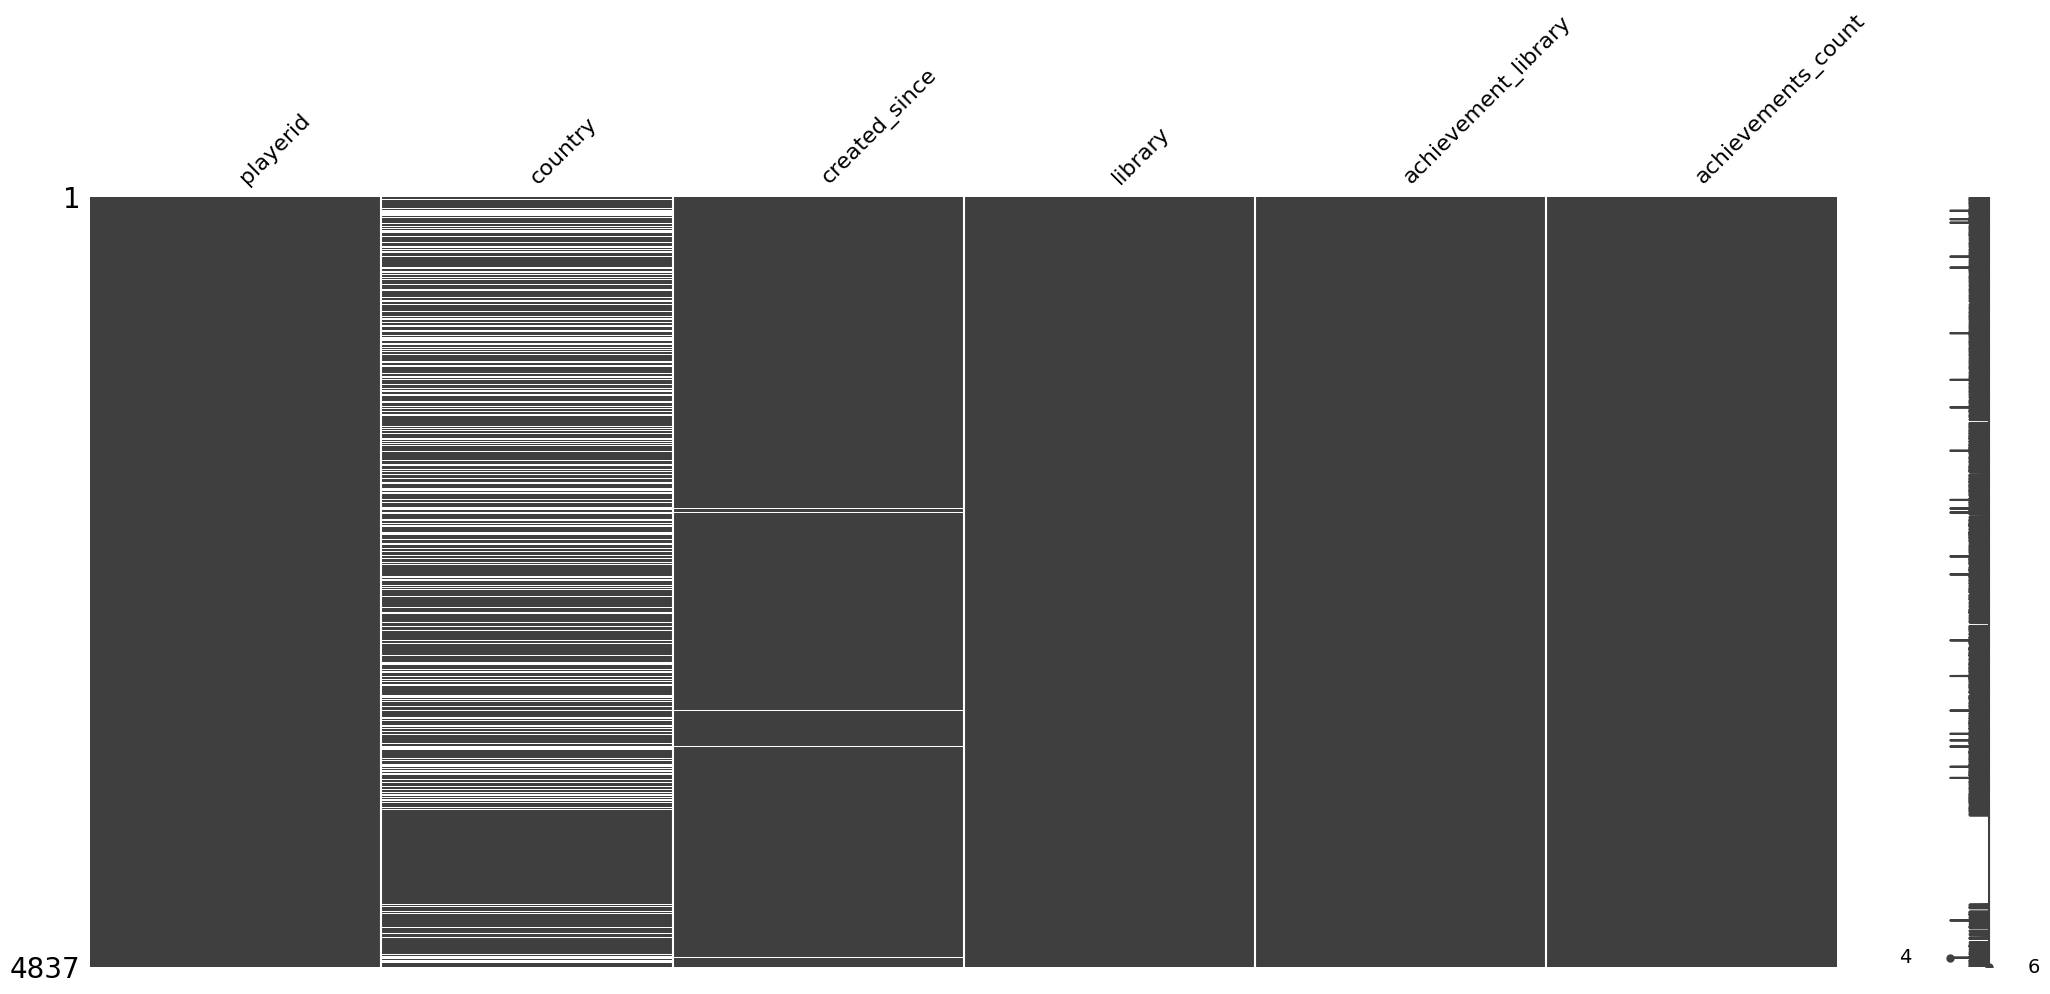

In [20]:
# Verificando a Matriz de Nulidade do dataframe

ms.matrix(players_atual_f)

Para a coluna *created_since* e *country* irei preencher com os respectivos valores: 01-01-1900 data extrema para permitir identificar nas análises posteriormente e 'Sem país' para quem não preencheu o país.

In [21]:
# Preenchendo os dados NaN da coluna country

players_atual_f.loc[:, 'country'] = players_atual_f.loc[:, 'country'].fillna('Sem país')

players_atual_f

,playerid,country,created_since,library,achievement_library,achievements_count
15,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...","[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
20,76561197997318138,Finland,2008-03-15 22:42:49,"[300, 9060, 4570, 4580, 9310, 9450, 4760, 4770...","[351030, 218620, 296490, 577940, 583760, 56729...","[1300, 800, 419, 346, 303, 302, 294, 285, 266,..."
33,76561198087768441,Sem país,2013-03-31 20:07:25,"[240, 219150, 241540, 320040, 389730, 525480, ...","[878750, 1794680, 1328670, 1299120, 1385730, 1...","[3000, 196, 127, 100, 100, 100, 100, 100, 100,..."
45,76561198046388487,Russian Federation,2011-08-05 00:57:09,"[280, 360, 1200, 6840, 37400, 37420, 11390, 23...","[200710, 55230, 20920, 252950, 18500, 231740, ...","[77, 67, 45, 41, 38, 34, 34, 30, 27, 26, 21, 2..."
47,76561198056486056,Italy,2012-01-05 10:34:13,"[240, 55150, 201790, 257750, 303390, 303720, 3...","[232090, 240, 218620, 233130, 222880, 243800, ...","[182, 139, 94, 86, 83, 77, 75, 70, 61, 55, 54,..."
...,...,...,...,...,...,...
410610,76561198020338031,Sem país,2010-01-26 20:10:26,"[10, 80, 100, 221640, 300, 20, 30, 40, 50, 60,...","[550, 292030, 230410, 1599340, 601150, 8930, 2...","[61, 56, 56, 55, 54, 51, 50, 50, 50, 49, 48, 4..."
410620,76561198031552455,United Kingdom,2010-10-07 18:42:23,"[359320, 1113560, 582660, 232090, 4000, 23310,...","[976730, 232090, 632360, 105600, 1250, 434650,...","[317, 119, 85, 85, 82, 60, 51, 51, 50, 47, 46,..."
410916,76561198948346059,Sem país,2019-04-01 13:44:21,"[322330, 291550, 730, 1046930, 406970, 424840,...",[578080],[8]
411216,76561199095221014,Norway,2020-10-01 14:23:45,"[500, 550, 230410, 236390, 265630, 273110, 225...","[550, 500, 945360, 346330, 1477830, 714010, 35...","[80, 34, 17, 14, 7, 6, 2, 1, 1]"


In [22]:
# Preenchendo a coluna created_since com a data 01/01/1900 quando houver NaN

players_atual_f.loc[:, 'created_since'] = players_atual_f.loc[:, 'created_since'].fillna(pd.Timestamp('1900-01-01'))

players_atual_f

,playerid,country,created_since,library,achievement_library,achievements_count
15,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...","[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
20,76561197997318138,Finland,2008-03-15 22:42:49,"[300, 9060, 4570, 4580, 9310, 9450, 4760, 4770...","[351030, 218620, 296490, 577940, 583760, 56729...","[1300, 800, 419, 346, 303, 302, 294, 285, 266,..."
33,76561198087768441,Sem país,2013-03-31 20:07:25,"[240, 219150, 241540, 320040, 389730, 525480, ...","[878750, 1794680, 1328670, 1299120, 1385730, 1...","[3000, 196, 127, 100, 100, 100, 100, 100, 100,..."
45,76561198046388487,Russian Federation,2011-08-05 00:57:09,"[280, 360, 1200, 6840, 37400, 37420, 11390, 23...","[200710, 55230, 20920, 252950, 18500, 231740, ...","[77, 67, 45, 41, 38, 34, 34, 30, 27, 26, 21, 2..."
47,76561198056486056,Italy,2012-01-05 10:34:13,"[240, 55150, 201790, 257750, 303390, 303720, 3...","[232090, 240, 218620, 233130, 222880, 243800, ...","[182, 139, 94, 86, 83, 77, 75, 70, 61, 55, 54,..."
...,...,...,...,...,...,...
410610,76561198020338031,Sem país,2010-01-26 20:10:26,"[10, 80, 100, 221640, 300, 20, 30, 40, 50, 60,...","[550, 292030, 230410, 1599340, 601150, 8930, 2...","[61, 56, 56, 55, 54, 51, 50, 50, 50, 49, 48, 4..."
410620,76561198031552455,United Kingdom,2010-10-07 18:42:23,"[359320, 1113560, 582660, 232090, 4000, 23310,...","[976730, 232090, 632360, 105600, 1250, 434650,...","[317, 119, 85, 85, 82, 60, 51, 51, 50, 47, 46,..."
410916,76561198948346059,Sem país,2019-04-01 13:44:21,"[322330, 291550, 730, 1046930, 406970, 424840,...",[578080],[8]
411216,76561199095221014,Norway,2020-10-01 14:23:45,"[500, 550, 230410, 236390, 265630, 273110, 225...","[550, 500, 945360, 346330, 1477830, 714010, 35...","[80, 34, 17, 14, 7, 6, 2, 1, 1]"


Com o tratamento dos dados concluído podemos verificar a matriz novamente

<Axes: >

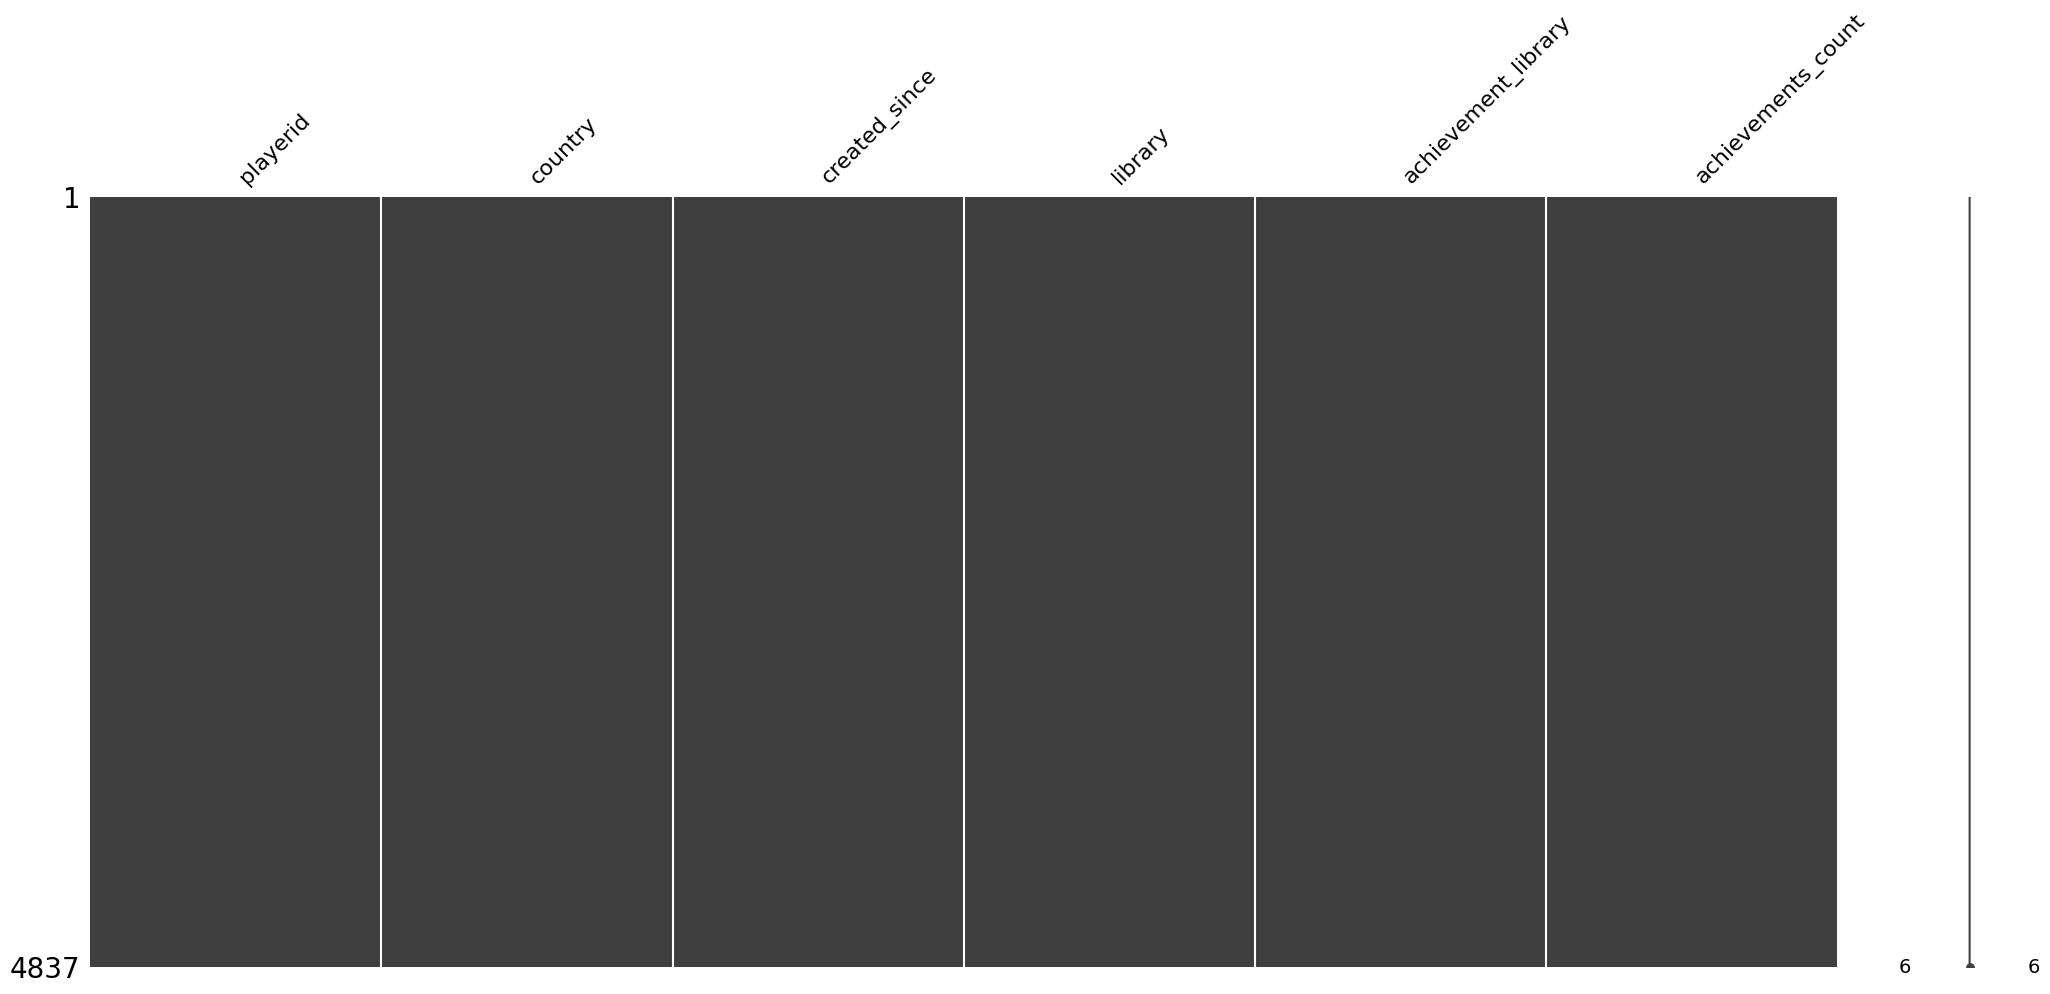

In [23]:
# Conferindo a matriz novamente

ms.matrix(players_atual_f)

Com a filtragem feita os dados estão completos. Irei proseguir agora para o conjunto **games_atual**

In [24]:
# tranformando o dataframe em csv

players_atual_f.to_csv('players_final.csv', index=False)

## Limpeza do conjunto **games_atual**
O conjunto games_atual, dependendo de como irá ocorrer a limpeza é necessário manter dados remanescentes, para após excluirmos suas referências do conjunto players_atual. Irei dar seguimento realizando os mesmos procedimentos feitos no conjunto anterior porém agora visando deixar no conjunto apenas dados que remetem a jogos completos(Que não seja demonstrações e nem playtest).

In [25]:
# Visualizando os dados do conjunto

games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
0,3281560,Horror Game To Play With Friends! Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
1,3280930,Eternals' Path Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
2,3280770,ANGST: A TALE OF SURVIVAL - Singleplayer Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
3,3279790,Montabi Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
4,3278320,파이팅걸 유리 Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24,1.79,1.79,234.0,59.0
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99,0.99,0.89,120.0,42.0


Visualizando os dados de **games_atual** notei em *title* que alguns jogos tem ao final de seu nome "Playtest", isso indica que o jogo é uma versão de teste sendo possível jogá-lo apenas e determinado período. Este tipo de jogo em questão não contém muitos dados no conjunto, os motivos são porque ele é uma versão temporária incompleta e porque é fornecido gratuitamente.<br>
A seguir irei reallizar a filtragem dos dados com "Playtest" em *title* para ter uma ideia do quão completo eles são.

In [26]:
# Realizando a filtragem dos dados

filtro = games_atual['title'].str.contains('Playtest', case=False, na=False)  # Variavel com os requisitos de filtragem, deve conter playtest no nome não importando
                                                                              # o tamanho da letra.
games_atual[filtro]

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
0,3281560,Horror Game To Play With Friends! Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
1,3280930,Eternals' Path Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
2,3280770,ANGST: A TALE OF SURVIVAL - Singleplayer Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
3,3279790,Montabi Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
4,3278320,파이팅걸 유리 Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
98100,1502740,Harvest Island Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
98115,1502090,Diamond Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
98129,1501580,Mad Devils Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
98230,1499140,Steel Crew Playtest,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN


A princípio todos os dados são do tipo considerado antes, porém para ter certeza de que não temos nenhum jogo que seja sobre playtest (contém playtest no nome) irei filtrar pelos dados em comum entre todos os playtest de verdade.<br>
Considerando que quando um jogo é playtest ele não tem valor de mercado, pois não é um jogo concluído, podemos filtrar por estas colunas em que um jogo playtest seria nulo. Assim encontrando algum jogo que tenha passado.

In [27]:
# Realizando a filtragem

games_tmp = games_atual[filtro]  # Atribuindo o dataframe filtrado a uma variavel temporária

filtro = games_tmp[['usd', 'eur', 'gbp', 'jpy', 'rub']].notna().any(axis=1)  # Criando um filtro que retorna somente os valores que tenham algum valor nas colunas de moeda

games_tmp[filtro]

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub


O filtro não retornou nenhum dado, o que indica que 100% dos jogos contidos na primeira filtragem são playtests.<br>
Seguindo para exclusão dos dados do conjunto principal

In [28]:
# Exclusão dos dados do conjunto principal

games_playtest = games_tmp  # Renomeando a variavel para games_playtest

filtro = games_atual['gameid'].isin(games_playtest['gameid']) # Filtro para caso o gameid do dataframe games_atual esteja dentro de gameid ele retorne a linha

games_atual = games_atual[~filtro]  # Utilizando o filtro com o simbolo de negação ~ para envés de retornar o dado o excluí-lo.

games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",0,2.49,2.49,2.14,290.0,100.0
10,3270850,Keep Your Eyes Open,['Texerikus'],['Texerikus'],['Indie'],['English'],0,3.99,3.99,3.89,470.0,165.0
15,3267350,Tiny Shooters,['madilumar'],['Thetinyverse'],"['Action', 'Free To Play']",['English'],0,NaN,NaN,NaN,NaN,NaN
17,3266470,Futanari Sex Adventures - Episode 5,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2,4.99,NaN,4.29,580.0,200.0
20,3264110,AUTO_BATTLER_RPG,['Kadragon Games'],['Kadragon Games'],"['Casual', 'RPG']",['English'],0,1.79,1.79,1.49,210.0,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24,1.79,1.79,234.0,59.0
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99,0.99,0.89,120.0,42.0


O próximo passo agora é verificar os dados NaN nas colunas para podermos preenche-las se necessário da melhor forma possível.

<Axes: >

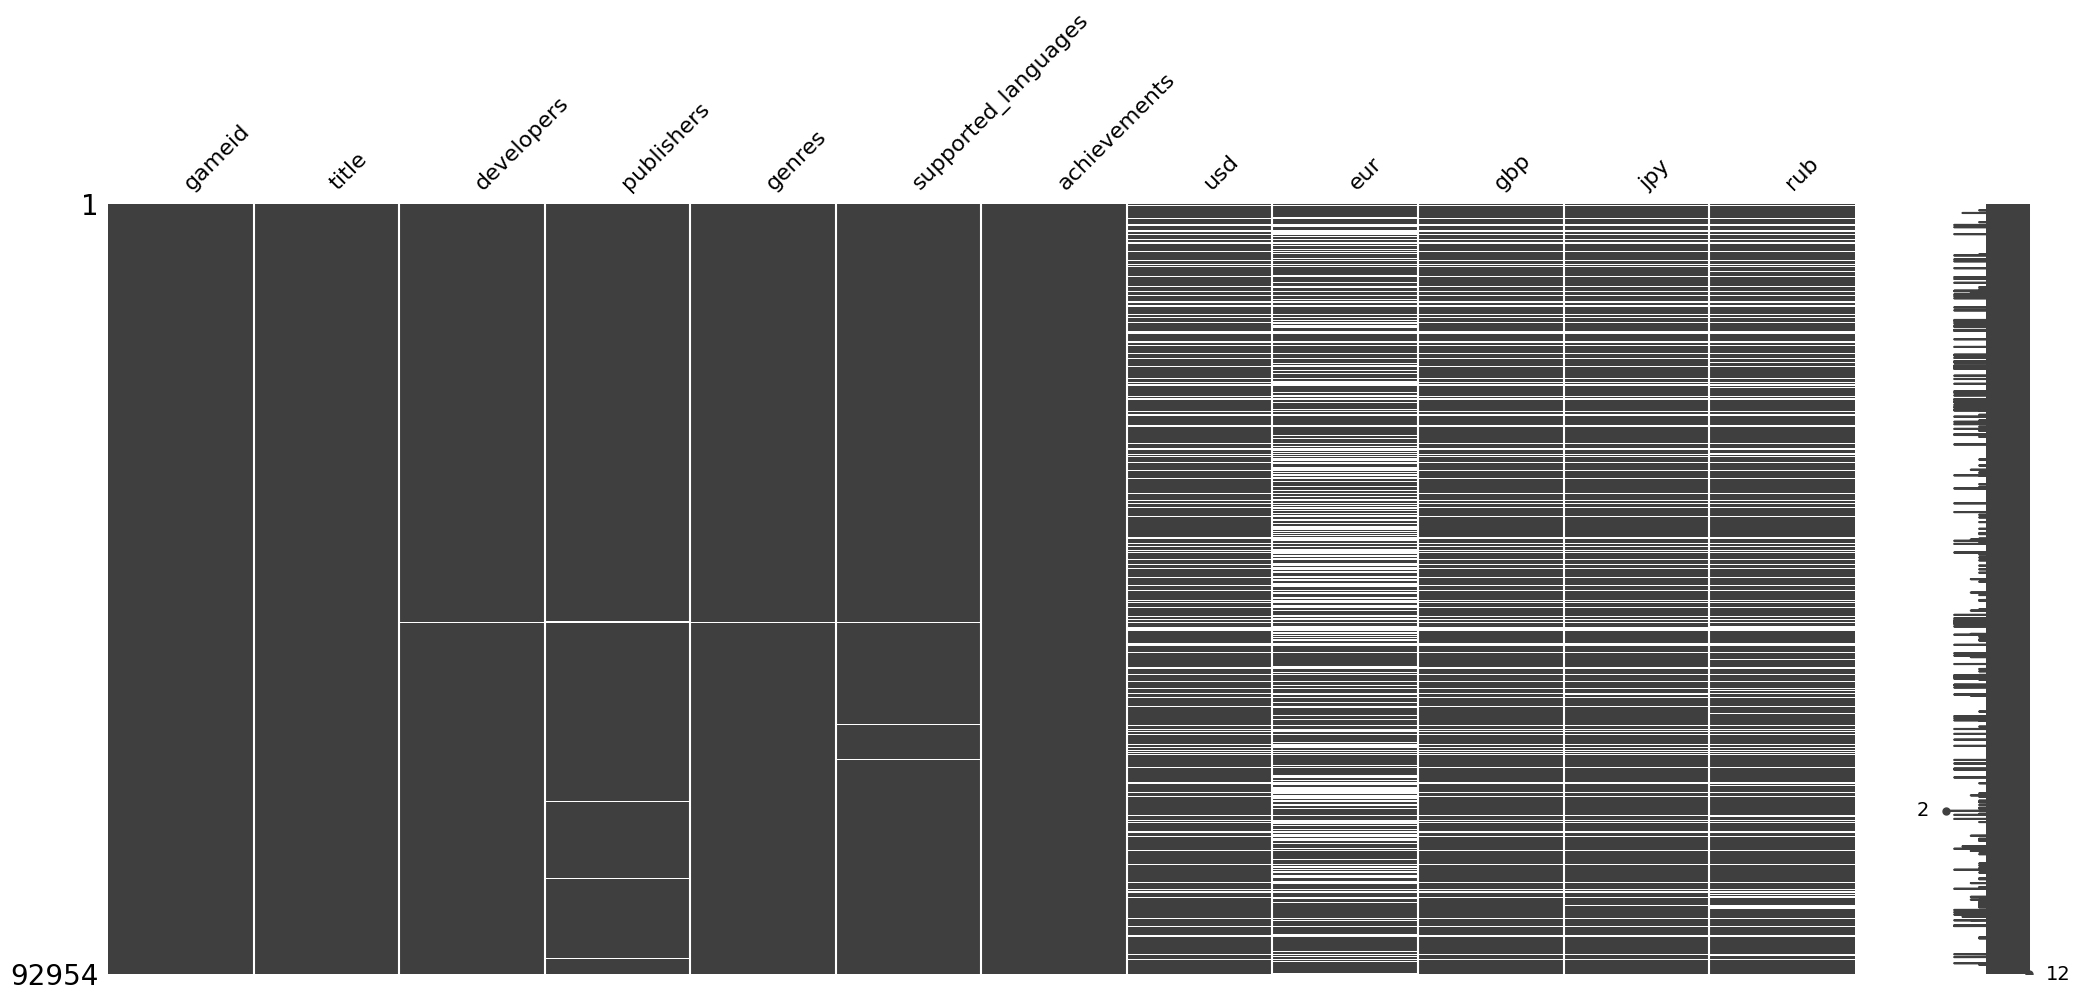

In [29]:
# Verificando os dados faltantes nas colunas

ms.matrix(games_atual)

É notável que a maior parte dos dados NaN ficam na área das moedas, com isso irei filtrar os dados faltantes das colunas *developers, publishers, genres, supported_languages* e irei analisar para ver quais serão necessários excluir e quais manter.

In [30]:
# Filtrando os dados NaN das colunas

filtro = games_atual[['developers', 'publishers', 'genres', 'supported_languages']].isnull().any(axis=1)

games_tmp = games_atual[filtro]

games_tmp

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
229,1427570,Pepe's Revenge,"['Carlos Bott', 'FractalDev Games']",NaN,"['Action', 'Early Access']",['English'],0,4.99,4.99,4.29,580.0,200.0
357,1423340,PolygonDuty,['FanaticStudios'],NaN,"['Action', 'Adventure', 'Indie']",['English'],1,5.00,15.99,14.49,1950.0,415.0
651,1413780,TECHPACK,['TechDev'],NaN,"['Action', 'Indie']",['English'],7,4.99,3.99,3.99,520.0,133.0
808,1409670,Bright Memory: Infinite Ray Tracing Benchmark,['FYQD-Studio'],"['FYQD-Studio', 'PLAYISM']",NaN,"['English', 'French', 'German', 'Spanish - Lat...",0,NaN,NaN,NaN,NaN,NaN
983,1403080,Radioactive Dwarfs: Evil From The Sewers,['Slay Buherman'],NaN,"['Action', 'Adventure', 'Indie']","['English', 'Russian', 'Traditional Chinese']",38,4.99,4.99,4.50,580.0,200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
97090,1532190,Halo: CE Mod Tools - MCC,"['343 Industries', 'Splash Damage', 'Ruffian G...",['Xbox Game Studios'],NaN,['English'],0,NaN,NaN,NaN,NaN,NaN
97316,1525190,Monster Outbreak,['GameMunchers'],NaN,"['Action', 'Adventure', 'Indie', 'RPG', 'Strat...","['English', 'French', 'German', 'Spanish - Spa...",40,4.49,4.19,3.59,480.0,165.0
97320,1525330,Guardians of Hyelore,['Megaglope Studios'],NaN,"['Action', 'Indie', 'Strategy']","['English', 'French', 'Italian', 'German', 'Sp...",64,3.99,3.69,3.09,460.0,142.0
97576,1517520,Foglight Online,['DangerousBob Studio LLC'],NaN,"['Action', 'Indie']",['English'],10,7.99,6.59,5.79,820.0,195.0


Pelo que pude notar vendo a visualização é:
- Jogos que não possuem genêro podem não ser jogos, em sua maioria são ferramentas de criação, que apesar de muito raro na Steam, existem. Então todos que não possuem dados em genêros serão excluídos.<br>

- De acordo com o cenário atual de desenvolvimento de jogos, os jogos 'indies' ou independentes podem não possuir uma publisher(Editora/Publicadora) responsável pelo marketing do jogo. Logo terei de preencher os dados com algum tipo que seja neutro e não impacte no desempenho em análises futuras, como uma lista vazia "[]" que é do mesmo tipo trabalhado na coluna.<br>

- Jogos que não tem desenvolvedora serão excluídos do dataframe, pois jogos devem ter pelo menos uma desenvolvedora para as análises futuras.<br>

- Em relação à coluna *suported_languages* após as exclusões do dataframe **games_atual** irei filtrar para ver quais tipos de jogos que são, porém muito provavelmente seja um erro na coleta de dados, sendo assim preenchido com lista vazia.

In [31]:
# Realizando as mudanças na coluna genre

games_no_genres = games_atual[games_atual['genres'].isnull()]  # Realiza a filtragem dos dados NaN da coluna genres

filtro = games_atual['gameid'].isin(games_no_genres['gameid']) # filtro para selecionar todos os dados que estão no dataframe games_no_genres

games_atual = games_atual[~filtro]  # Realiza a exclusão dos dados NaN selecionados

games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",0,2.49,2.49,2.14,290.0,100.0
10,3270850,Keep Your Eyes Open,['Texerikus'],['Texerikus'],['Indie'],['English'],0,3.99,3.99,3.89,470.0,165.0
15,3267350,Tiny Shooters,['madilumar'],['Thetinyverse'],"['Action', 'Free To Play']",['English'],0,NaN,NaN,NaN,NaN,NaN
17,3266470,Futanari Sex Adventures - Episode 5,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2,4.99,NaN,4.29,580.0,200.0
20,3264110,AUTO_BATTLER_RPG,['Kadragon Games'],['Kadragon Games'],"['Casual', 'RPG']",['English'],0,1.79,1.79,1.49,210.0,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24,1.79,1.79,234.0,59.0
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99,0.99,0.89,120.0,42.0


In [32]:
# Realizando as mudanças na coluna developers

games_no_developers = games_atual[games_atual['developers'].isnull()]  # Realiza a filtragem

filtro = games_atual['gameid'].isin(games_no_developers['gameid'])

games_atual = games_atual[~filtro]

games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",0,2.49,2.49,2.14,290.0,100.0
10,3270850,Keep Your Eyes Open,['Texerikus'],['Texerikus'],['Indie'],['English'],0,3.99,3.99,3.89,470.0,165.0
15,3267350,Tiny Shooters,['madilumar'],['Thetinyverse'],"['Action', 'Free To Play']",['English'],0,NaN,NaN,NaN,NaN,NaN
17,3266470,Futanari Sex Adventures - Episode 5,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2,4.99,NaN,4.29,580.0,200.0
20,3264110,AUTO_BATTLER_RPG,['Kadragon Games'],['Kadragon Games'],"['Casual', 'RPG']",['English'],0,1.79,1.79,1.49,210.0,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24,1.79,1.79,234.0,59.0
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99,0.99,0.89,120.0,42.0


In [33]:
# Realizando a mudança da coluna publishers

games_atual.loc[:, 'publishers'] = games_atual.loc[:, 'publishers'].fillna('[]')  # Preenchendo os dados NaN com uma lista vazia em formato string

games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",0,2.49,2.49,2.14,290.0,100.0
10,3270850,Keep Your Eyes Open,['Texerikus'],['Texerikus'],['Indie'],['English'],0,3.99,3.99,3.89,470.0,165.0
15,3267350,Tiny Shooters,['madilumar'],['Thetinyverse'],"['Action', 'Free To Play']",['English'],0,NaN,NaN,NaN,NaN,NaN
17,3266470,Futanari Sex Adventures - Episode 5,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2,4.99,NaN,4.29,580.0,200.0
20,3264110,AUTO_BATTLER_RPG,['Kadragon Games'],['Kadragon Games'],"['Casual', 'RPG']",['English'],0,1.79,1.79,1.49,210.0,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24,1.79,1.79,234.0,59.0
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99,0.99,0.89,120.0,42.0


In [34]:
# Filtrando os dados NaN da coluna supported_languages

filtro = games_atual[['supported_languages']].isnull().any(axis=1)

games_tmp = games_atual[filtro]

games_tmp.head(40)

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
2247,1366270,Primal Carnage: Extinction - Workshop Tool,['Circle 5 Studios'],['Circle 5 Studios'],['Action'],NaN,0,NaN,NaN,NaN,NaN,NaN
5666,2738460,Never wake up,['ToquiGames'],['ToquiGames'],['Indie'],NaN,0,4.99,4.99,4.29,580.0,200.0
9385,1818790,Maze Art: Orange,['My Label Game Studio'],['My Label Game Studio'],"['Casual', 'Indie']",NaN,100,1.99,NaN,1.69,205.0,61.0
9386,1818800,Maze Art: Pink,['My Label Game Studio'],['My Label Game Studio'],"['Casual', 'Indie']",NaN,100,1.99,NaN,1.69,205.0,61.0
9387,1818810,Maze Art: Purple,['My Label Game Studio'],['My Label Game Studio'],"['Casual', 'Indie']",NaN,100,1.99,NaN,1.69,205.0,61.0
9388,1818820,Maze Art: Rainbow,['My Label Game Studio'],['My Label Game Studio'],"['Casual', 'Indie']",NaN,100,1.99,NaN,1.69,205.0,61.0
9389,1818830,Maze Art: Red,['My Label Game Studio'],['My Label Game Studio'],"['Casual', 'Indie']",NaN,100,1.99,NaN,1.69,205.0,61.0
9390,1818840,Maze Art: Yellow,['My Label Game Studio'],['My Label Game Studio'],"['Casual', 'Indie']",NaN,100,1.99,NaN,1.69,205.0,61.0
9458,1816410,Maze Art: Brown,['My Label Game Studio'],['My Label Game Studio'],['Indie'],NaN,100,4.99,NaN,4.29,580.0,200.0
9459,1816420,Maze Art: Green,['My Label Game Studio'],['My Label Game Studio'],"['Casual', 'Indie']",NaN,100,1.99,NaN,1.69,205.0,61.0


Como o esperado a coluna *supported_languages* apresenta jogos que não declararam na plataforma as linguagens compativeis com seus jogos, e não é necessáriamente um erro da coleta. Para preenchimento irei preencher com lista vazia assim como a coluna *publishers*.

In [35]:
# Preenchendo a coluna supported_languages

games_atual.loc[:, 'supported_languages'] = games_atual.loc[:, 'supported_languages'].fillna('[]')

games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",0,2.49,2.49,2.14,290.0,100.0
10,3270850,Keep Your Eyes Open,['Texerikus'],['Texerikus'],['Indie'],['English'],0,3.99,3.99,3.89,470.0,165.0
15,3267350,Tiny Shooters,['madilumar'],['Thetinyverse'],"['Action', 'Free To Play']",['English'],0,NaN,NaN,NaN,NaN,NaN
17,3266470,Futanari Sex Adventures - Episode 5,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2,4.99,NaN,4.29,580.0,200.0
20,3264110,AUTO_BATTLER_RPG,['Kadragon Games'],['Kadragon Games'],"['Casual', 'RPG']",['English'],0,1.79,1.79,1.49,210.0,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24,1.79,1.79,234.0,59.0
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99,0.99,0.89,120.0,42.0


Agora que preenchi todos os dados que não são as moedas vou visualizar a Matriz de Nulidade novamente

<Axes: >

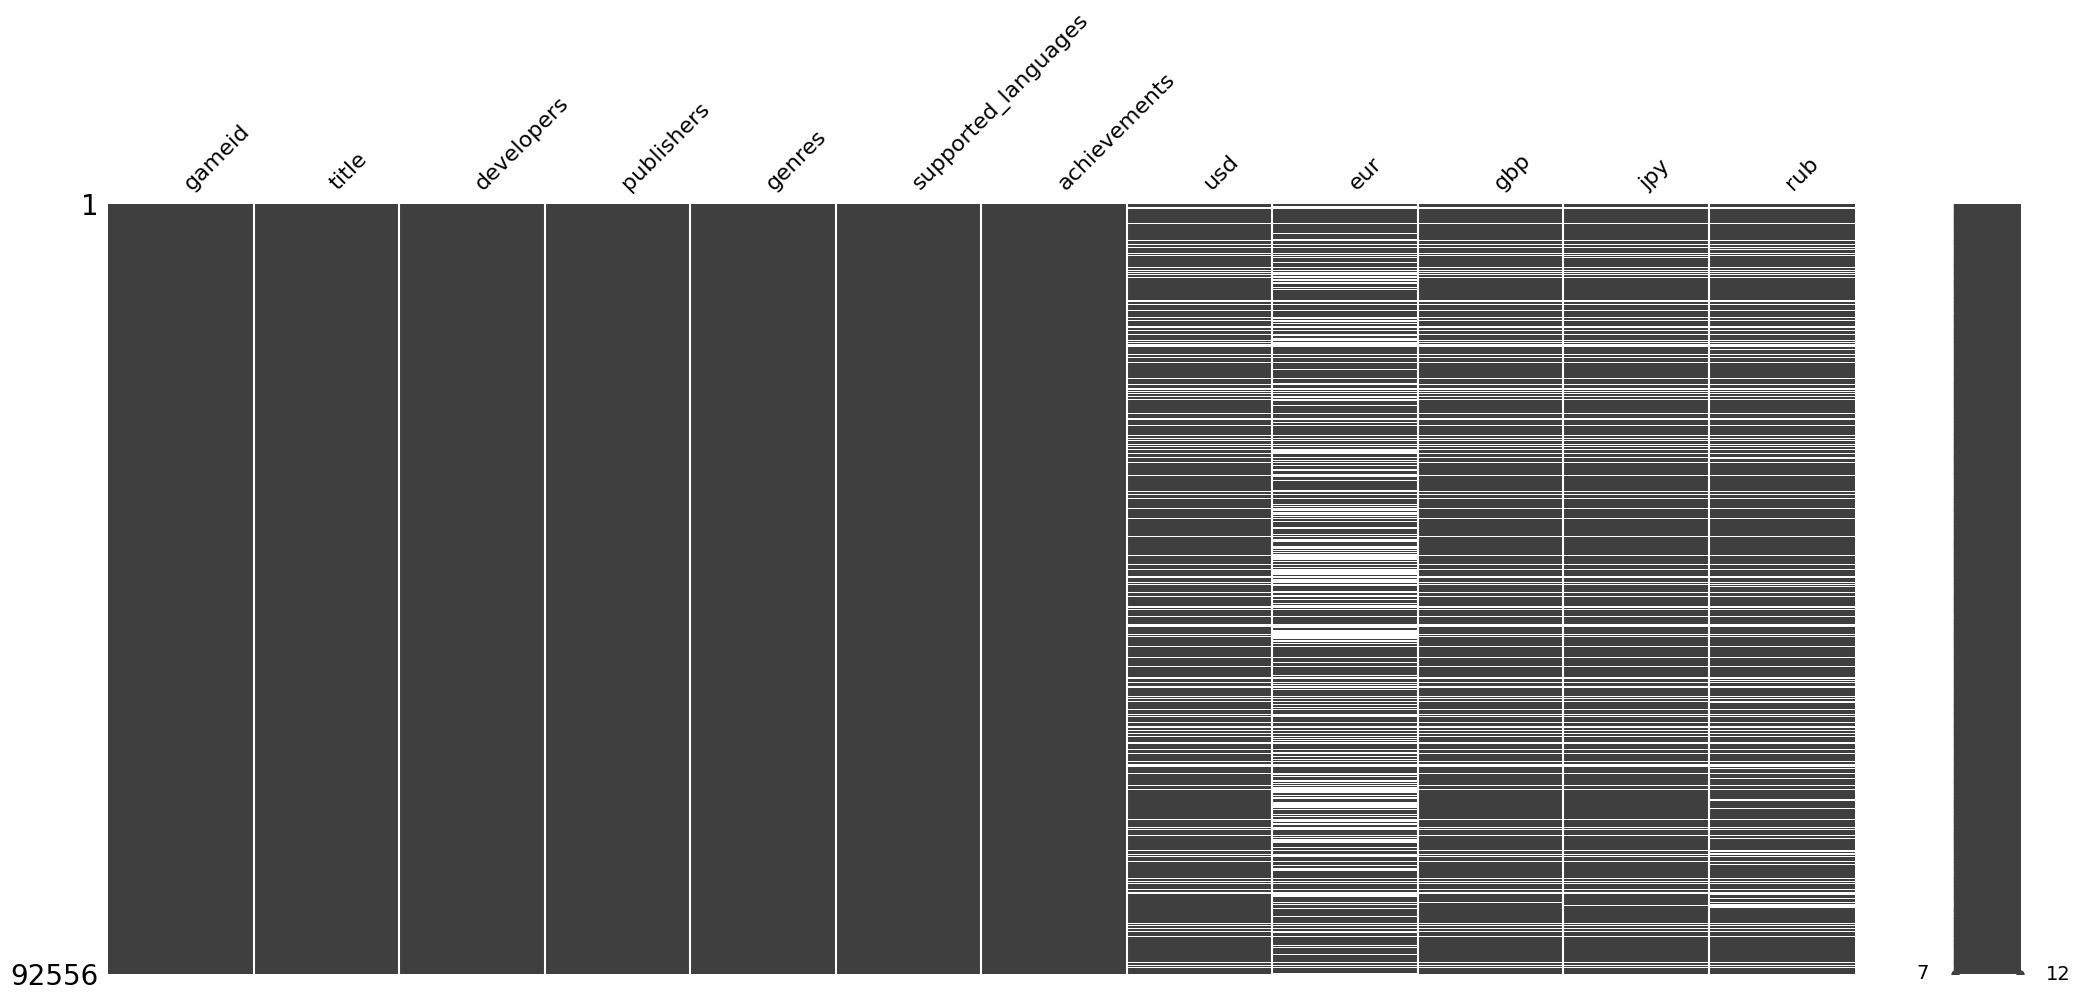

In [36]:
# Visualizando a matriz

ms.matrix(games_atual)

Agora em relação as moedas irei converter todas para um só tipo e então modificar os dados indefinidos para 0.<br>
Começando pela conversão, não é aconselhado realizar conversão direta de uma moeda para outra pois o preço de um mesmo jogo difere entre paises, geralmente em paises que a população não tem alto poder de compra os jogos são de valor mais baixo do que a média de preço dos outros países.<br>
Irei converter todos os preços para Moeda dólar na coluna *usd*, para os jogos que não tem o valor em dólar irei propositalmente converter da moeda Euro presente na coluna *eur* para dólar pois ambas possuem o valor mais aproximado de conversão na lista.

Para iniciar a conversão primeiro irei definir uma hierarquia de substituição de valores que é:
- Caso a coluna *usd* esteja preenchida: Não é necessário nenhuma ação;
- Caso a coluna *usd* não esteja preenchida: Irei pegar o valor da coluna *eur* converte-la e então preencher o espaço;
- Caso a coluna *eur* não esteja preenchida: Irei pegar o valor da coluna *gbp*;

E assim por diante sendo as proxima a coluna *rub* e a última *jpy* todas definidas em relação a sua proximidade a moeda alvo.

In [37]:
# Aplicando a conversão às colunas de acordo com a cotação do dolár em relação ao dia de coleta das informações da moeda. dia 24/02/2025

conversao = {'eur': 1.046, 'gbp': 1.262, 'rub': 0.01140, 'jpy': 0.001167}

for col in conversao:
    games_atual.loc[:, col] = games_atual.loc[:, col] * conversao[col]


games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",0,2.49,2.60454,2.70068,0.338430,1.1400
10,3270850,Keep Your Eyes Open,['Texerikus'],['Texerikus'],['Indie'],['English'],0,3.99,4.17354,4.90918,0.548490,1.8810
15,3267350,Tiny Shooters,['madilumar'],['Thetinyverse'],"['Action', 'Free To Play']",['English'],0,NaN,NaN,NaN,NaN,NaN
17,3266470,Futanari Sex Adventures - Episode 5,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2,4.99,NaN,5.41398,0.676860,2.2800
20,3264110,AUTO_BATTLER_RPG,['Kadragon Games'],['Kadragon Games'],"['Casual', 'RPG']",['English'],0,1.79,1.87234,1.88038,0.245070,0.8550
...,...,...,...,...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24,1.87234,2.25898,0.273078,0.6726
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99,1.03554,1.12318,0.140040,0.4788


In [38]:
# Preenchendo os dados NaN com os valores convertidos
games_atual = games_atual.copy()  # Realizando uma copia do proprio dataframe para evitar warning

# Combinando as colunas para que caso um esteja ausente pegue o próximo da hierarquia
games_atual['usd'] = (games_atual['usd'].combine_first(games_atual['eur']).combine_first(games_atual['gbp']).combine_first(games_atual['rub']).combine_first(games_atual['jpy']))

games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",0,2.49,2.60454,2.70068,0.338430,1.1400
10,3270850,Keep Your Eyes Open,['Texerikus'],['Texerikus'],['Indie'],['English'],0,3.99,4.17354,4.90918,0.548490,1.8810
15,3267350,Tiny Shooters,['madilumar'],['Thetinyverse'],"['Action', 'Free To Play']",['English'],0,NaN,NaN,NaN,NaN,NaN
17,3266470,Futanari Sex Adventures - Episode 5,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2,4.99,NaN,5.41398,0.676860,2.2800
20,3264110,AUTO_BATTLER_RPG,['Kadragon Games'],['Kadragon Games'],"['Casual', 'RPG']",['English'],0,1.79,1.87234,1.88038,0.245070,0.8550
...,...,...,...,...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,NaN,NaN,NaN,NaN,NaN
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24,1.87234,2.25898,0.273078,0.6726
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99,1.03554,1.12318,0.140040,0.4788


Agora que o preechimento com dados de outras moedas foi concluido irei realizar o preechimento dos dados que ainda estão inválidos com zero

In [39]:
# Preenchendo os dados invalidos da coluna usd com zero

games_atual['usd'] = games_atual['usd'].fillna(0)

games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd,eur,gbp,jpy,rub
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",0,2.49,2.60454,2.70068,0.338430,1.1400
10,3270850,Keep Your Eyes Open,['Texerikus'],['Texerikus'],['Indie'],['English'],0,3.99,4.17354,4.90918,0.548490,1.8810
15,3267350,Tiny Shooters,['madilumar'],['Thetinyverse'],"['Action', 'Free To Play']",['English'],0,0.00,NaN,NaN,NaN,NaN
17,3266470,Futanari Sex Adventures - Episode 5,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2,4.99,NaN,5.41398,0.676860,2.2800
20,3264110,AUTO_BATTLER_RPG,['Kadragon Games'],['Kadragon Games'],"['Casual', 'RPG']",['English'],0,1.79,1.87234,1.88038,0.245070,0.8550
...,...,...,...,...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,0.00,NaN,NaN,NaN,NaN
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,0.00,NaN,NaN,NaN,NaN
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24,1.87234,2.25898,0.273078,0.6726
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99,1.03554,1.12318,0.140040,0.4788


Após o preenchimento total dos dados irei excluir as colunas das outras moedas.

In [40]:
# Excluindo as colunas obsoletas

games_atual = games_atual.drop(columns=['eur', 'gbp', 'rub', 'jpy'])

games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",0,2.49
10,3270850,Keep Your Eyes Open,['Texerikus'],['Texerikus'],['Indie'],['English'],0,3.99
15,3267350,Tiny Shooters,['madilumar'],['Thetinyverse'],"['Action', 'Free To Play']",['English'],0,0.00
17,3266470,Futanari Sex Adventures - Episode 5,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2,4.99
20,3264110,AUTO_BATTLER_RPG,['Kadragon Games'],['Kadragon Games'],"['Casual', 'RPG']",['English'],0,1.79
...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,0.00
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,0.00
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99


Agora com o dataframe já ajustado e a coluna *usd* preenchida irei formatar os valores para 2 casas decimais apenas. Assim como se encontrava inicialmente.

In [41]:
# Formatando os dados de usd para duas casas decimais

games_atual['usd'] = games_atual['usd'].round(2)

games_atual

,gameid,title,developers,publishers,genres,supported_languages,achievements,usd
5,3278740,NEURO,['Revolt Games'],['Strategy First'],['Action'],"['English', 'Russian']",0,2.49
10,3270850,Keep Your Eyes Open,['Texerikus'],['Texerikus'],['Indie'],['English'],0,3.99
15,3267350,Tiny Shooters,['madilumar'],['Thetinyverse'],"['Action', 'Free To Play']",['English'],0,0.00
17,3266470,Futanari Sex Adventures - Episode 5,['EroticGamesClub'],['EroticGamesClub'],"['Adventure', 'Casual', 'Indie']",['English'],2,4.99
20,3264110,AUTO_BATTLER_RPG,['Kadragon Games'],['Kadragon Games'],"['Casual', 'RPG']",['English'],0,1.79
...,...,...,...,...,...,...,...,...
98243,1499520,Spiritwish,['NEONSTUDIO Corp.'],['SUBETE'],"['Adventure', 'Casual', 'Free To Play', 'Massi...",['Japanese'],0,0.00
98244,1499540,リアルタイムバトル将棋オンライン,['株式会社シルバースタージャパン'],['株式会社シルバースタージャパン'],"['Action', 'Free To Play', 'Simulation', 'Stra...",['Japanese'],0,0.00
98245,1499550,VR Luxury Life (Be a Billionaire),['William at Oxford'],['William at Oxford'],"['Casual', 'Simulation']","['English', 'French', 'Italian', 'German', 'Sp...",0,2.24
98246,1498590,Fat Prisoner Simulator 3,['Kiddy'],['Kiddy'],"['Indie', 'Simulation', 'Sports']",['English'],0,0.99


Após realizar todos os processos para retirar e preencher os dados não definidos, irei agora ver se é possível converter os dados da coluna genres para colunas multiplas com marcações de 0 ou 1.<br>

Isso só será possível caso a quantidade maxima de diferentes gêneros sejam menor que 15 (Valor estipulado por mim).<br>

Irei iniciar a verificação.

In [42]:
# Verificando quantos elementos a coluna genres tem.

genres = games_atual['genres']  # Capturando somente a coluna genres

genres = genres.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)  # Convertendo de string para list, a coluna genres

genres = genres.explode()  # Convertendo cada lista para linhas unicas

len(genres.value_counts().index.tolist()) # Contando quantos dados únicos tinham dentro da coluna genres

33

In [43]:
# Verificando quantos elementos a coluna supported_languages tem.

languages = games_atual['supported_languages']  # Capturando somente a coluna supported_languages

languages = languages.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)  # Convertendo de string para list, a coluna supported_languages

languages = languages.explode()  # Convertendo cada lista para linhas unicas

len(languages.value_counts().index.tolist()) # Contando quantos dados únicos tinham dentro da coluna supported_languages

135

As duas colunas não se encaixam para nenhuma forma de padronização como o one-hot encoding ou dummy encode. Caso seja aplicado em genres que é a quantidade menor de dados, dificultaria a contagem em sí, tendo em vista que precisaria conciliar 33 colunas para retirar alguma contagem disso.

Limpeza dos dados do conjunto **games_atual** foi finalizada.

<Axes: >

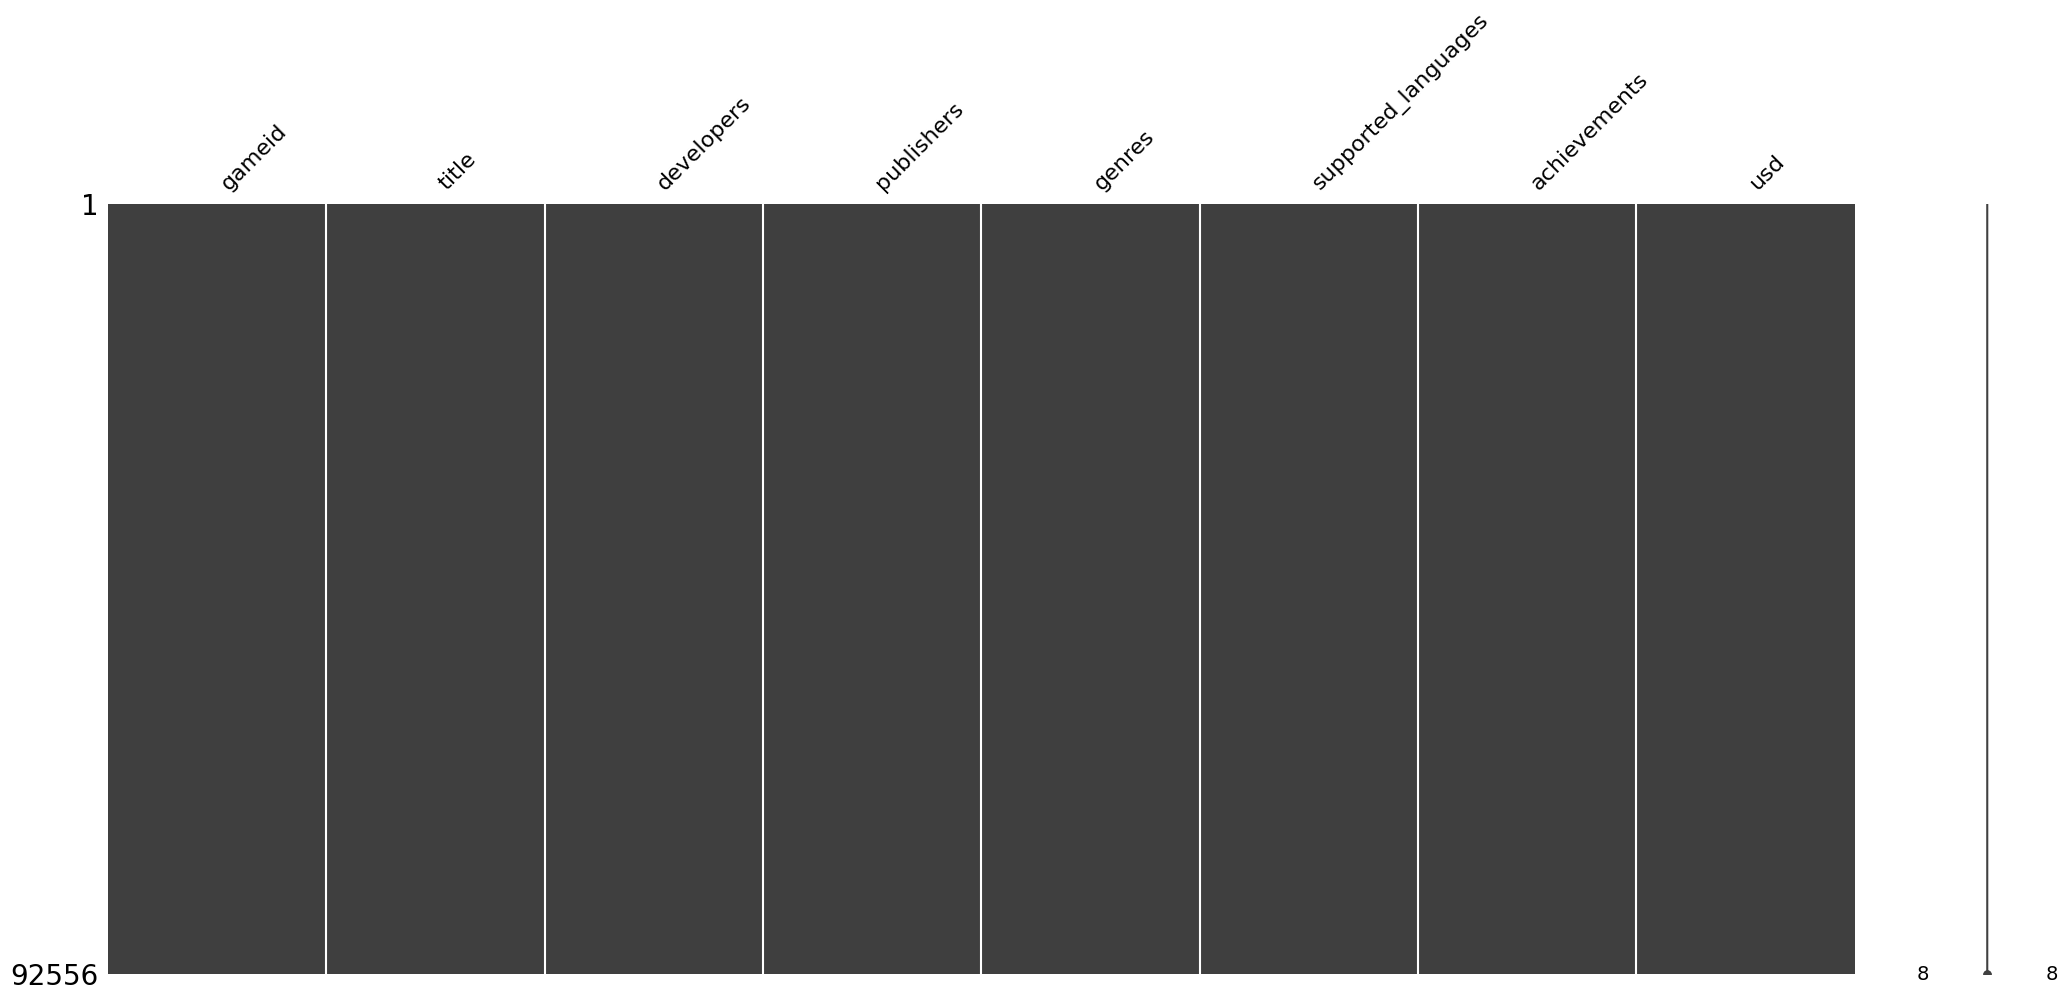

In [44]:
# exibição da matriz de nulidade

ms.matrix(games_atual)

In [45]:
games_atual.to_csv('games_final.csv', index=False)

## Ajustes finais no conjunto **players_atual**

Com os ajustes realizados no conjunto **games_atual** é necessário a exclusão dos jogos que foram retirados durante a limpeza do conjunto

In [46]:
# Estanciando o dataframe player

players = pd.read_csv('players_final.csv')

In [47]:
# Estendendo as listas das colunas achievement_library e achievements_count

player_tmp = players.copy()  # Criando uma cópia que será manipulada
player_atual = players.copy()  # Criando uma cópia que será atualizada

player_tmp['achievement_library'] = player_tmp['achievement_library'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x) # convertendo as listas para list
player_tmp['achievements_count'] = player_tmp['achievements_count'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x) # convertendo as listas para list

player_tmp = player_tmp.explode(column=['achievement_library', 'achievements_count'], ignore_index=True)  # Como as duas listas são sincronizadas, eu extendi elas juntas.

player_tmp

,playerid,country,created_since,library,achievement_library,achievements_count
0,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...",218620,452
1,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...",1172620,131
2,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...",1328670,95
3,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...",1293830,93
4,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...",648800,77
...,...,...,...,...,...,...
275635,76561198138610183,Thailand,2014-05-31 08:48:21,"[6860, 550, 105600, 222980, 51100, 113420, 391...",413150,19
275636,76561198138610183,Thailand,2014-05-31 08:48:21,"[6860, 550, 105600, 222980, 51100, 113420, 391...",444090,4
275637,76561198138610183,Thailand,2014-05-31 08:48:21,"[6860, 550, 105600, 222980, 51100, 113420, 391...",105600,4
275638,76561198138610183,Thailand,2014-05-31 08:48:21,"[6860, 550, 105600, 222980, 51100, 113420, 391...",304930,1


In [48]:
# Realizando a exclusão das linhas que contenham o id do achievement_library dentro dos dataframes games_playtest, games_no_genres e games_no_developers

filtro_playtest = player_tmp['achievement_library'].isin(games_playtest['gameid'])  # filtro para identificar os jogos que são playtests

filtro_no_genres = player_tmp['achievement_library'].isin(games_no_genres['gameid'])  # filtro para identificar os jogos que não tem gêneros

filtro_no_developers = player_tmp['achievement_library'].isin(games_no_developers['gameid'])  # filtro para identificar os jogos que não tem desenvolvedores

# Aplicando os filtros com simbolo de negação para serem desconsiderados
player_tmp = player_tmp[~filtro_playtest]

player_tmp = player_tmp[~filtro_no_genres]

player_tmp = player_tmp[~filtro_no_developers]

player_tmp

/tmp/ipython-input-48-3563306760.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  player_tmp = player_tmp[~filtro_no_developers]


,playerid,country,created_since,library,achievement_library,achievements_count
0,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...",218620,452
1,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...",1172620,131
2,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...",1328670,95
3,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...",1293830,93
4,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...",648800,77
...,...,...,...,...,...,...
275635,76561198138610183,Thailand,2014-05-31 08:48:21,"[6860, 550, 105600, 222980, 51100, 113420, 391...",413150,19
275636,76561198138610183,Thailand,2014-05-31 08:48:21,"[6860, 550, 105600, 222980, 51100, 113420, 391...",444090,4
275637,76561198138610183,Thailand,2014-05-31 08:48:21,"[6860, 550, 105600, 222980, 51100, 113420, 391...",105600,4
275638,76561198138610183,Thailand,2014-05-31 08:48:21,"[6860, 550, 105600, 222980, 51100, 113420, 391...",304930,1


In [49]:
# Reagrupando os dados em suas devidas listas

player_tmp = player_tmp.groupby('playerid')[['achievement_library', 'achievements_count']].agg(list).reset_index()

player_tmp

,playerid,achievement_library,achievements_count
0,76561197960272169,"[806140, 640310, 866510, 812140, 367520, 87078...","[3003, 1333, 81, 65, 47, 42, 41, 34, 29, 27, 2..."
1,76561197960324512,"[238960, 214950, 364360, 1794680, 252950, 5945...","[97, 86, 84, 73, 66, 56, 53, 50, 47, 45, 42, 4..."
2,76561197960335869,"[485450, 585830, 690740, 860910, 806140, 77696...","[5000, 5000, 4536, 3445, 3003, 2975, 1502, 500..."
3,76561197960355806,"[221380, 238960, 582010, 813780, 389730, 63897...","[45, 32, 21, 17, 12, 9, 6, 3, 3, 1]"
4,76561197960376165,"[252950, 1794680, 546430, 588650, 202170, 2969...","[54, 52, 40, 38, 33, 32, 30, 29, 29, 28, 28, 2..."
...,...,...,...
4832,76561199650216656,"[578080, 730]","[12, 1]"
4833,76561199651812604,"[504230, 367520, 2670630, 431960, 714010, 730,...","[7, 5, 2, 2, 2, 1, 1]"
4834,76561199680871825,[1245620],[31]
4835,76561199681893932,"[240, 1818450, 730]","[4, 1, 1]"


In [50]:
# Juntando os dados na lista atual

player_atual = player_atual.merge(player_tmp, on='playerid', how='inner')  # Realizando a junção dos dataframes

player_atual = player_atual.drop(columns=['achievement_library_x', 'achievements_count_x']) # Excluindo as colunas antigas

player_atual = player_atual.rename(columns={'achievement_library_y': 'achievement_library', 'achievements_count_y': 'achievements_count'}) # Renomeando as colunas novas para o nome padrão

player_atual

,playerid,country,created_since,library,achievement_library,achievements_count
0,76561198220441373,Ukraine,2015-09-28 12:48:59,"[2100, 2130, 3830, 220240, 214510, 292910, 350...","[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
1,76561197997318138,Finland,2008-03-15 22:42:49,"[300, 9060, 4570, 4580, 9310, 9450, 4760, 4770...","[351030, 218620, 296490, 577940, 583760, 56729...","[1300, 800, 419, 346, 303, 302, 294, 285, 266,..."
2,76561198087768441,Sem país,2013-03-31 20:07:25,"[240, 219150, 241540, 320040, 389730, 525480, ...","[878750, 1794680, 1328670, 1299120, 1385730, 1...","[3000, 196, 127, 100, 100, 100, 100, 100, 100,..."
3,76561198046388487,Russian Federation,2011-08-05 00:57:09,"[280, 360, 1200, 6840, 37400, 37420, 11390, 23...","[200710, 55230, 20920, 252950, 18500, 231740, ...","[77, 67, 45, 41, 38, 34, 34, 30, 27, 26, 21, 2..."
4,76561198056486056,Italy,2012-01-05 10:34:13,"[240, 55150, 201790, 257750, 303390, 303720, 3...","[232090, 240, 218620, 233130, 222880, 243800, ...","[182, 139, 94, 86, 83, 77, 75, 70, 61, 55, 54,..."
...,...,...,...,...,...,...
4832,76561198020338031,Sem país,2010-01-26 20:10:26,"[10, 80, 100, 221640, 300, 20, 30, 40, 50, 60,...","[550, 292030, 230410, 1599340, 601150, 8930, 2...","[61, 56, 56, 55, 54, 51, 50, 50, 50, 49, 48, 4..."
4833,76561198031552455,United Kingdom,2010-10-07 18:42:23,"[359320, 1113560, 582660, 232090, 4000, 23310,...","[976730, 232090, 632360, 105600, 1250, 434650,...","[317, 119, 85, 85, 82, 60, 51, 51, 50, 47, 46,..."
4834,76561198948346059,Sem país,2019-04-01 13:44:21,"[322330, 291550, 730, 1046930, 406970, 424840,...",[578080],[8]
4835,76561199095221014,Norway,2020-10-01 14:23:45,"[500, 550, 230410, 236390, 265630, 273110, 225...","[550, 500, 945360, 346330, 1477830, 714010, 35...","[80, 34, 17, 14, 7, 6, 2, 1, 1]"


Abaixo irei realizar os mesmos processos com a coluna library

In [51]:
# Realizando a extensão das listas da coluna library

player_tmp = player_atual.copy()

player_tmp['library'] = player_tmp['library'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

player_tmp = player_tmp.explode(column=['library'], ignore_index=True)

player_tmp

,playerid,country,created_since,library,achievement_library,achievements_count
0,76561198220441373,Ukraine,2015-09-28 12:48:59,2100,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
1,76561198220441373,Ukraine,2015-09-28 12:48:59,2130,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
2,76561198220441373,Ukraine,2015-09-28 12:48:59,3830,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
3,76561198220441373,Ukraine,2015-09-28 12:48:59,220240,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
4,76561198220441373,Ukraine,2015-09-28 12:48:59,214510,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
...,...,...,...,...,...,...
1156193,76561198138610183,Thailand,2014-05-31 08:48:21,252850,"[218620, 1172620, 413150, 444090, 105600, 3049...","[616, 82, 19, 4, 4, 1, 1]"
1156194,76561198138610183,Thailand,2014-05-31 08:48:21,1172620,"[218620, 1172620, 413150, 444090, 105600, 3049...","[616, 82, 19, 4, 4, 1, 1]"
1156195,76561198138610183,Thailand,2014-05-31 08:48:21,346110,"[218620, 1172620, 413150, 444090, 105600, 3049...","[616, 82, 19, 4, 4, 1, 1]"
1156196,76561198138610183,Thailand,2014-05-31 08:48:21,407530,"[218620, 1172620, 413150, 444090, 105600, 3049...","[616, 82, 19, 4, 4, 1, 1]"


In [52]:
# Realizando a exclusão das linhas que contenham o id da coluna library dentro dos dataframes games_playtest, games_no_genres e games_no_developers

filtro_playtest = player_tmp['library'].isin(games_playtest['gameid'])

filtro_no_genres = player_tmp['library'].isin(games_no_genres['gameid'])

filtro_no_developers = player_tmp['library'].isin(games_no_developers['gameid'])

player_tmp = player_tmp[~filtro_playtest]

player_tmp = player_tmp[~filtro_no_genres]

player_tmp = player_tmp[~filtro_no_developers]

player_tmp

/tmp/ipython-input-52-3042411922.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  player_tmp = player_tmp[~filtro_no_developers]


,playerid,country,created_since,library,achievement_library,achievements_count
0,76561198220441373,Ukraine,2015-09-28 12:48:59,2100,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
1,76561198220441373,Ukraine,2015-09-28 12:48:59,2130,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
2,76561198220441373,Ukraine,2015-09-28 12:48:59,3830,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
3,76561198220441373,Ukraine,2015-09-28 12:48:59,220240,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
4,76561198220441373,Ukraine,2015-09-28 12:48:59,214510,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,..."
...,...,...,...,...,...,...
1156193,76561198138610183,Thailand,2014-05-31 08:48:21,252850,"[218620, 1172620, 413150, 444090, 105600, 3049...","[616, 82, 19, 4, 4, 1, 1]"
1156194,76561198138610183,Thailand,2014-05-31 08:48:21,1172620,"[218620, 1172620, 413150, 444090, 105600, 3049...","[616, 82, 19, 4, 4, 1, 1]"
1156195,76561198138610183,Thailand,2014-05-31 08:48:21,346110,"[218620, 1172620, 413150, 444090, 105600, 3049...","[616, 82, 19, 4, 4, 1, 1]"
1156196,76561198138610183,Thailand,2014-05-31 08:48:21,407530,"[218620, 1172620, 413150, 444090, 105600, 3049...","[616, 82, 19, 4, 4, 1, 1]"


In [53]:
# Realizando o agrupamento das listas novamente

player_tmp = player_tmp.groupby('playerid')['library'].agg(list).reset_index()

player_tmp

,playerid,library
0,76561197960272169,"[39190, 238170, 224060, 242050, 257890, 277450..."
1,76561197960324512,"[10, 20, 30, 40, 50, 60, 70, 130, 774941, 2361..."
2,76561197960335869,"[10, 20, 30, 40, 50, 60, 70, 130, 220, 34460, ..."
3,76561197960355806,"[10, 20, 30, 40, 50, 60, 70, 130, 1332010, 220..."
4,76561197960376165,"[10, 20, 30, 40, 50, 60, 70, 130, 249570, 2145..."
...,...,...
4832,76561199650216656,"[8650, 272060, 346290, 298180, 397720, 552990,..."
4833,76561199651812604,"[367520, 291550, 431960, 311210, 504230, 51914..."
4834,76561199680871825,"[730, 1245620, 578080, 2909110]"
4835,76561199681893932,"[240, 730, 1818450]"


In [54]:
# Realizando a junção dos dados para player_atual

player_atual = player_atual.merge(player_tmp, on='playerid', how='inner')

player_atual = player_atual.drop(columns=['library_x'])

player_atual = player_atual.rename(columns={'library_y': 'library'})

player_atual

,playerid,country,created_since,achievement_library,achievements_count,library
0,76561198220441373,Ukraine,2015-09-28 12:48:59,"[218620, 1172620, 1328670, 1293830, 648800, 29...","[452, 131, 95, 93, 77, 73, 72, 70, 66, 62, 60,...","[2100, 2130, 3830, 220240, 214510, 292910, 350..."
1,76561197997318138,Finland,2008-03-15 22:42:49,"[351030, 218620, 296490, 577940, 583760, 56729...","[1300, 800, 419, 346, 303, 302, 294, 285, 266,...","[300, 9060, 4570, 4580, 9310, 9450, 4760, 4770..."
2,76561198087768441,Sem país,2013-03-31 20:07:25,"[878750, 1794680, 1328670, 1299120, 1385730, 1...","[3000, 196, 127, 100, 100, 100, 100, 100, 100,...","[240, 219150, 241540, 320040, 389730, 525480, ..."
3,76561198046388487,Russian Federation,2011-08-05 00:57:09,"[200710, 55230, 20920, 252950, 18500, 231740, ...","[77, 67, 45, 41, 38, 34, 34, 30, 27, 26, 21, 2...","[280, 360, 1200, 6840, 37400, 37420, 23380, 20..."
4,76561198056486056,Italy,2012-01-05 10:34:13,"[232090, 240, 218620, 233130, 222880, 243800, ...","[182, 139, 94, 86, 83, 77, 75, 70, 61, 55, 54,...","[240, 55150, 201790, 257750, 303390, 303720, 3..."
...,...,...,...,...,...,...
4832,76561198020338031,Sem país,2010-01-26 20:10:26,"[550, 292030, 230410, 1599340, 601150, 8930, 2...","[61, 56, 56, 55, 54, 51, 50, 50, 50, 49, 48, 4...","[10, 80, 100, 221640, 300, 20, 30, 40, 50, 60,..."
4833,76561198031552455,United Kingdom,2010-10-07 18:42:23,"[976730, 232090, 632360, 105600, 1250, 434650,...","[317, 119, 85, 85, 82, 60, 51, 51, 50, 47, 46,...","[359320, 1113560, 582660, 232090, 4000, 23310,..."
4834,76561198948346059,Sem país,2019-04-01 13:44:21,[578080],[8],"[322330, 291550, 730, 1046930, 406970, 424840,..."
4835,76561199095221014,Norway,2020-10-01 14:23:45,"[550, 500, 945360, 346330, 1477830, 714010, 35...","[80, 34, 17, 14, 7, 6, 2, 1, 1]","[500, 550, 230410, 236390, 265630, 273110, 225..."


Agora que os dados foram ajustados irei realizar a transformação para csv para melhor acesso aos dados posteriormente.

In [55]:
# Realizando a criação do arquivo
player_atual.to_csv('players_final.csv', index=False)

# Análise e visualização dos dados
Chegou a hora de focar em achar as respostas para os problemas e a seguir irei realizar as análises para definir as soluções.

## Checkpoint de dados análise e visualização

Como realizei muitas operações antes da análise e visualização dos dados. Irei reestanciar os dataframes com o csv gerado ao final de cada tratamento. Para assim durante a codificação, caso haja algum comando que mude os dados por definitivo, não seja necessário executar todo o tratamento novamente.

In [56]:
# Estanciando o dataframe players_atual como players

players = pd.read_csv('players_final.csv')

# Estanciando o dataframe games_atual como games

games = pd.read_csv('games_final.csv')

## Retomando as hipóteses do problema

###É possível que um usuário adquira jogos e não os jogue?

Eu irei responder esta pergunta com base nos jogos que o usuário possui em sua biblioteca (*coluna library*) e sua biblioteca com os jogos que tem no minimo um achievement (*coluna achievement_library*). O dado chave para saber se ele iniciou ou não será se ele tem algum achievement em jogos que tenham achievements.

Neste primeiro trecho de código criarei um dataframe novo que servirá para extrair os dados para as visualizações. Neste dataframe ele vai ter como base todos os jogos do usuário, os jogos que ele possui alguma conquista e a quantidade total de conquistas por jogo.

In [57]:
# Capturando os dados para estender as colunas de library para cada usuário

library = players.copy()
achievement_library = players.copy()

achievement_library['achievement_library'] = achievement_library['achievement_library'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
achievement_library['achievements_count'] = achievement_library['achievements_count'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

library['library'] = library['library'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

library = library.explode(column=['library'], ignore_index=True)

achievement_library = achievement_library.explode(column=['achievement_library', 'achievements_count'], ignore_index=True)

In [58]:
# Realizando a formatação dos dataframes para sua junção

library = library.drop(columns=['created_since', 'country', 'achievement_library', 'achievements_count'])

library = library.rename(columns={'library': 'gameid_library'})

achievement_library = achievement_library.drop(columns=['created_since', 'country', 'library'])

achievement_library = achievement_library.rename(columns={'achievement_library': 'gameid_library'})

In [59]:
# Realizando a junção dos dois dataframes em apenas um

library = library.merge(achievement_library, on=['playerid', 'gameid_library'], how='left')

library

,playerid,gameid_library,achievements_count
0,76561198220441373,2100,NaN
1,76561198220441373,2130,NaN
2,76561198220441373,3830,NaN
3,76561198220441373,220240,NaN
4,76561198220441373,214510,3
...,...,...,...
1150883,76561198138610183,252850,NaN
1150884,76561198138610183,1172620,82
1150885,76561198138610183,346110,NaN
1150886,76561198138610183,407530,NaN


In [60]:
# Iremos capturar a quantidade de conquistas em cada jogo e então comparar

achievement = games.copy()

achievement = achievement[['gameid', 'achievements']]

achievement = achievement.rename(columns={'achievements': 'total_achievements', 'gameid': 'gameid_library'})

In [61]:
# Iremos juntar o total de achievements com o dataframe library

library = library.merge(achievement, on='gameid_library', how='left')

library

,playerid,gameid_library,achievements_count,total_achievements
0,76561198220441373,2100,NaN,0.0
1,76561198220441373,2130,NaN,0.0
2,76561198220441373,3830,NaN,37.0
3,76561198220441373,220240,NaN,0.0
4,76561198220441373,214510,3,48.0
...,...,...,...,...
1150883,76561198138610183,252850,NaN,49.0
1150884,76561198138610183,1172620,82,270.0
1150885,76561198138610183,346110,NaN,32.0
1150886,76561198138610183,407530,NaN,0.0


In [62]:
# ajustando os valores para -1 se o total for 0 e 0 se o total for maior que 0

library['achievements_count'] = library.apply(lambda linha: 0 if linha['total_achievements'] > 0 and pd.isna(linha['achievements_count']) else -1 if linha['total_achievements'] == 0 and pd.isna(linha['achievements_count']) else linha['achievements_count'], axis=1)

library

,playerid,gameid_library,achievements_count,total_achievements
0,76561198220441373,2100,-1.0,0.0
1,76561198220441373,2130,-1.0,0.0
2,76561198220441373,3830,0.0,37.0
3,76561198220441373,220240,-1.0,0.0
4,76561198220441373,214510,3.0,48.0
...,...,...,...,...
1150883,76561198138610183,252850,0.0,49.0
1150884,76561198138610183,1172620,82.0,270.0
1150885,76561198138610183,346110,0.0,32.0
1150886,76561198138610183,407530,-1.0,0.0


In [63]:
# Adicionando uma coluna indicativa de quais jogos o usuário realizou algo e quais ele não realizou

library['has_achievements'] = library['achievements_count'].apply(lambda x: True if x > 0 else False if x == 0 else None)

library

,playerid,gameid_library,achievements_count,total_achievements,has_achievements
0,76561198220441373,2100,-1.0,0.0,None
1,76561198220441373,2130,-1.0,0.0,None
2,76561198220441373,3830,0.0,37.0,False
3,76561198220441373,220240,-1.0,0.0,None
4,76561198220441373,214510,3.0,48.0,True
...,...,...,...,...,...
1150883,76561198138610183,252850,0.0,49.0,False
1150884,76561198138610183,1172620,82.0,270.0,True
1150885,76561198138610183,346110,0.0,32.0,False
1150886,76561198138610183,407530,-1.0,0.0,None


In [64]:
# Contando quantos jogos os usuários jogaram de seu total

contagem = library.groupby('playerid')['has_achievements'].value_counts(dropna=False).unstack(fill_value=0).reset_index()
contagem['total'] = contagem[True] + contagem[False] + contagem[np.nan]

contagem_f = contagem.rename(columns={False: 'Não jogou', np.nan: 'Jogo sem conquista', True: 'Jogou'})

contagem_f

has_achievements,playerid,NaN,Não jogou,Jogou,total
0,76561197960272169,909,1249,188,2346
1,76561197960324512,90,70,92,252
2,76561197960335869,262,213,194,669
3,76561197960355806,26,18,10,54
4,76561197960376165,242,436,251,929
...,...,...,...,...,...
4832,76561199650216656,13,9,2,24
4833,76561199651812604,5,4,7,16
4834,76561199680871825,0,3,1,4
4835,76561199681893932,0,0,3,3


In [65]:
# Descrição dos dados com .describe

contagem_f.describe()

has_achievements,playerid,NaN,Não jogou,Jogou,total
count,4.837000e+03,4837.000000,4837.000000,4837.000000,4837.000000
mean,7.656120e+16,83.532148,97.597064,56.805044,237.934257
std,4.055546e+08,344.141559,473.409176,83.081551,850.998348
min,7.656120e+16,0.000000,0.000000,1.000000,1.000000
25%,7.656120e+16,10.000000,7.000000,11.000000,31.000000
50%,7.656120e+16,27.000000,19.000000,29.000000,79.000000
75%,7.656120e+16,62.000000,50.000000,69.000000,188.000000
max,7.656120e+16,10593.000000,14238.000000,1247.000000,24980.000000


Através do describe foi possível perceber que a média de jogos por usuário é de aproximadamente 237 jogos porém o seu desvio padrão é bem alto, o que indica que uma pequena parcela pode conter numeros muito acima da média de jogos. Provavelmente os jogadores mais antigos. Se for olhar a média de jogos por biblioteca jogados e não jogados podemos ver que os jogos jogados são bem menos e mais proximos de uma estimativa precisa tendo em vista que seu desvio-padrão é bem menor do que ao da contagem de jogos não jogados, então a estimativa de jogos não jogados pode ser muito maior.

In [66]:
# aplicando a correlação de pearson no dataframe

correlacao = contagem_f.corr(method='pearson')

correlacao

has_achievements,playerid,NaN,Não jogou,Jogou,total
has_achievements,,,,,
playerid,1.000000,-0.124339,-0.109432,-0.302074,-0.140650
NaN,-0.124339,1.000000,0.952345,0.476957,0.980750
Não jogou,-0.109432,0.952345,1.000000,0.472395,0.987544
Jogou,-0.302074,0.476957,0.472395,1.000000,0.553301
total,-0.140650,0.980750,0.987544,0.553301,1.000000


Olhando pela correlação podemos notar que quanto mais jogos a pessoa possui mais ela tende a jogar pois ela tem uma correlação mediana com o total de jogos, porém a tendência é que a quantidade de jogos não jogados aumente com a quantidade de jogos adquiridos, sendo esse aumento quase o dobro em relação a os jogos jogados.

<Axes: xlabel='has_achievements', ylabel='has_achievements'>

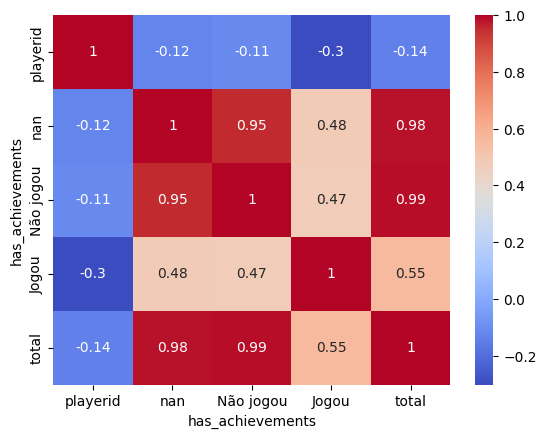

In [67]:
# Visualização da correlação com seaborn

sns.heatmap(correlacao, annot=True, cmap='coolwarm')

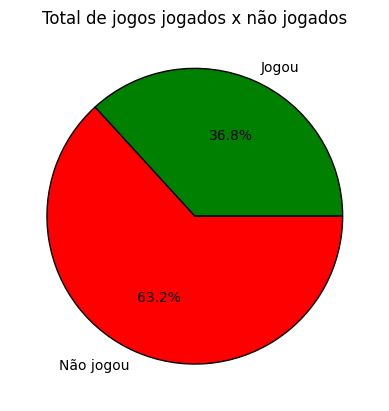

In [68]:
# Realizando a visualização do total de jogos que todos os jogadores não jogaram com o que os jogadores jogaram

total_jogados = contagem_f['Jogou'].sum()
total_nao_jogados = contagem_f['Não jogou'].sum()

labels = ['Jogou', 'Não jogou']
colors = ['#008000', '#ff0000']

plt.pie([total_jogados, total_nao_jogados], labels=labels, colors=colors, autopct='%1.1f%%', wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title('Total de jogos jogados x não jogados')
plt.show()

Através desde grafico podemos ver que os usuários adquirem mais jogos (com conquistas) do que jogam.

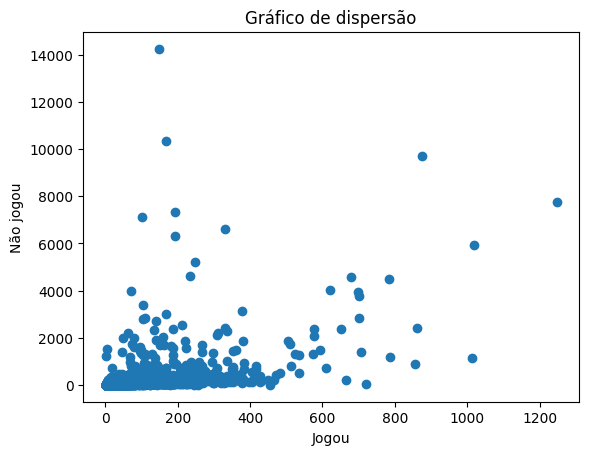

In [69]:
# Gráfico de dispersão

plt.scatter(contagem_f['Jogou'], contagem_f['Não jogou'])
plt.xlabel('Jogou')
plt.ylabel('Não jogou')
plt.title('Gráfico de dispersão')
plt.show()

Através do grafico de disperção podemos ver que a maioria dos usuários tem menos de 2000 jogos (Que contém conquistas) e jogam entre 0 a 400 jogos de sua biblioteca.

Podemos concluir que os usuários atuam como colecionadores de jogos, tendo em vista que quanto mais possuem, menos jogam jogos variados. Com isso a resposta para a pergunta é sim. É possivel que um usuário vá adquirindo jogos e os vai deixando em sua biblioteca.

###Um usuário gasta muito dinheiro para construir sua biblioteca?

Para esta questão irei realizar a junção do conjunto players junto com o conjunto games, para assim saber os valores de cada jogo para realizar os calculos e as análises.

In [70]:
# Relizando a estanciação dos conjuntos e os modificando

games_vlrs = games.copy()

players_lib = players.copy()

players_lib = players_lib.drop(columns=['created_since', 'country', 'achievement_library', 'achievements_count'])

games_vlrs = games_vlrs.drop(columns=['developers', 'publishers', 'genres', 'supported_languages', 'title', 'achievements'])

In [71]:
# Realizando a extensão das listas da coluna library de players

players_lib['library'] = players_lib['library'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

players_lib = players_lib.explode(column=['library'], ignore_index=True)

In [72]:
# Realizando a junção dos conjuntos para players_lib

players_lib = players_lib.rename(columns={'library': 'gameid'})

players_lib = players_lib.merge(games_vlrs, on='gameid', how='left')

players_lib

,playerid,gameid,usd
0,76561198220441373,2100,9.99
1,76561198220441373,2130,9.99
2,76561198220441373,3830,9.99
3,76561198220441373,220240,19.99
4,76561198220441373,214510,19.99
...,...,...,...
1150883,76561198138610183,252850,0.00
1150884,76561198138610183,1172620,39.99
1150885,76561198138610183,346110,14.99
1150886,76561198138610183,407530,0.00


Agora que o dataframe está pronto irei realizar as contagens para então começar as visualizações e definição de uma resposta para a hipótese.

In [73]:
# Realizando a somatória de valores para cada usuário da tabela

contagem_gastos = players_lib.groupby('playerid')['usd'].sum().reset_index()

contagem_gastos

,playerid,usd
0,76561197960272169,17061.57
1,76561197960324512,3853.73
2,76561197960335869,5242.74
3,76561197960355806,654.11
4,76561197960376165,15134.33
...,...,...
4832,76561199650216656,12.47
4833,76561199651812604,112.83
4834,76561199680871825,66.98
4835,76561199681893932,9.99


In [74]:
# Aplicando describe na coluna

contagem_gastos['usd'].describe()

,usd
count,4837.000000
mean,2395.911079
std,6921.207319
min,0.000000
25%,204.860000
50%,735.870000
75%,2169.140000
max,181654.150000


Notei que os usuários gastam bastante em relação a suas bibliotecas, isso se deve ao tempo que possuem as suas contas. Irei anexar o ano de criação das contas para ver se realmente é isso.

In [75]:
# anexando o ano de criação das contas

contagem_gastos = contagem_gastos.merge(players[['playerid', 'created_since']], on='playerid', how='left')

contagem_gastos

,playerid,usd,created_since
0,76561197960272169,17061.57,2003-09-12 12:03:18
1,76561197960324512,3853.73,2003-09-12 17:14:32
2,76561197960335869,5242.74,2003-09-12 18:02:05
3,76561197960355806,654.11,2003-09-12 19:23:55
4,76561197960376165,15134.33,2003-09-12 20:54:29
...,...,...,...
4832,76561199650216656,12.47,2024-03-06 04:07:57
4833,76561199651812604,112.83,2024-03-09 23:46:44
4834,76561199680871825,66.98,2024-04-28 08:52:01
4835,76561199681893932,9.99,1900-01-01 00:00:00


Agora terei de converter a data para poder manipulá-la e então tranformar a coluna data em uma coluna de tempo de conta

In [76]:
# Analisando a coluna created_since para poder realizar a operação para transformar a em tempo de conta.

contagem_gastos['created_since'] = pd.to_datetime(contagem_gastos['created_since'])

contagem_gastos['created_since'] = ((pd.Timestamp('2025-02-24') - contagem_gastos['created_since']).dt.days / 365.25).astype(int)

contagem_gastos['created_since'] = contagem_gastos['created_since'].apply(lambda x: 0 if x == 125 else x)

contagem_gastos

,playerid,usd,created_since
0,76561197960272169,17061.57,21
1,76561197960324512,3853.73,21
2,76561197960335869,5242.74,21
3,76561197960355806,654.11,21
4,76561197960376165,15134.33,21
...,...,...,...
4832,76561199650216656,12.47,0
4833,76561199651812604,112.83,0
4834,76561199680871825,66.98,0
4835,76561199681893932,9.99,0


In [77]:
# Renomeando a coluna created_since para account_age
idade_conta = contagem_gastos.copy()  # Irei utilizar posteriormente

contagem_gastos = contagem_gastos.rename(columns={'created_since': 'account_age'})

In [78]:
# Realizando a correlação dos valores

correlacao = contagem_gastos[['usd', 'account_age']].corr(method='pearson')

correlacao

,usd,account_age
usd,1.000000,0.239285
account_age,0.239285,1.000000


In [80]:
contagem_gastos[['usd', 'account_age']].describe()

,usd,account_age
count,4837.000000,4837.000000
mean,2395.911079,9.111639
std,6921.207319,3.972135
min,0.000000,0.000000
25%,204.860000,6.000000
50%,735.870000,9.000000
75%,2169.140000,11.000000
max,181654.150000,21.000000


Com esse detalhamento podemos ver que tem usuários com contas com tepo de 21 anos

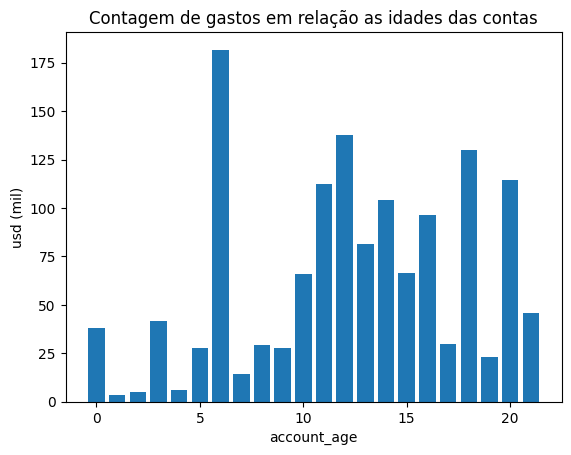

In [92]:
# Visualizando a contagem em um grafico de barras

plt.bar(contagem_gastos['account_age'], contagem_gastos['usd'] / 1e3)
plt.xlabel('account_age')
plt.ylabel('usd (mil)')
plt.title('Contagem de gastos em relação as idades das contas')
plt.show()

Visualizando o gráfico pude notar que entre as contas com 5 a 17 anos os usuários gastam mais, isto pode ser devido a promoções esporádicas que ocorrem na plataforma. O que faz os usuários adquirirem cada vez mais jogos.

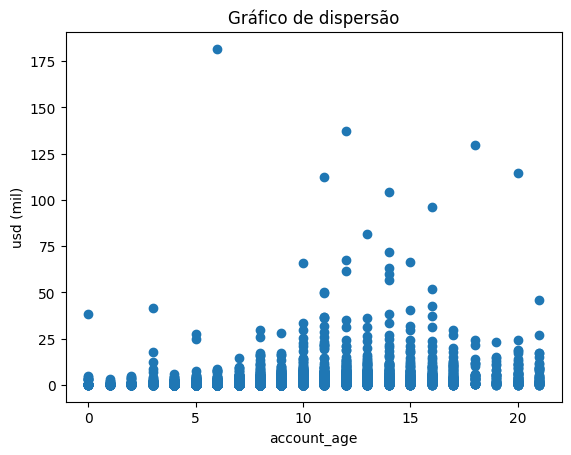

In [91]:
# Visualizando com scatter_plot

plt.scatter(contagem_gastos['account_age'], contagem_gastos['usd'] / 1e3)
plt.xlabel('account_age')
plt.ylabel('usd (mil)')
plt.title('Gráfico de dispersão')
plt.show()

Aqui pode-se ver melhor que a maioria dos jogadores se mantém em um valor de até 35 mil, e geralmente as contas chegam nesse valor em média a partir do 9º ano de conta.

Concluindo por mais que os jogadores gostem de acumular/colecionar jogos, apenas depois de um bom tempo de conta que a biblioteca do jogador passa a ser considerada cara.

###Tem algum gênero de jogo que é preferência pelos usuários?

Para a encontrar a reposta desta pergunta irei pegar os conjuntos players e games e agrupa-los para utilizar a distribuição de generos para cada jogo. Assim poderei saber por usuário qual genêro é o mais preferido.

In [93]:
# Capturando os dados dos conjuntos players e games

generos = players.copy()
generos_tmp = games.copy()

In [98]:
# Filtrando e excluindo colunas para melhor alinhamento

generos = generos.drop(columns=['created_since', 'country', 'achievement_library', 'achievements_count'])
generos_tmp = generos_tmp.drop(columns=['developers', 'publishers', 'supported_languages', 'title', 'achievements', 'usd'])

In [101]:
# Extendendo as listas da coluna library

generos['library'] = generos['library'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

generos = generos.explode(column=['library'], ignore_index=True)

generos = generos.rename(columns={'library': 'gameid'})

In [102]:
# Anexando os gêneros do conjunto games

generos = generos.merge(generos_tmp, on='gameid', how='left')

generos

,playerid,gameid,genres
0,76561198220441373,2100,"['Action', 'RPG']"
1,76561198220441373,2130,"['Action', 'RPG']"
2,76561198220441373,3830,['Action']
3,76561198220441373,220240,"['Action', 'Adventure']"
4,76561198220441373,214510,"['Action', 'Adventure']"
...,...,...,...
1150883,76561198138610183,252850,"['Action', 'Indie', 'Sports', 'Early Access']"
1150884,76561198138610183,1172620,"['Action', 'Adventure']"
1150885,76561198138610183,346110,"['Action', 'Adventure', 'Indie', 'Massively Mu..."
1150886,76561198138610183,407530,"['Action', 'Adventure', 'Indie', 'Massively Mu..."


In [103]:
# Extendendo a lista da coluna genres

generos['genres'] = generos['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

generos = generos.explode(column=['genres'], ignore_index=True)

generos

,playerid,gameid,genres
0,76561198220441373,2100,Action
1,76561198220441373,2100,RPG
2,76561198220441373,2130,Action
3,76561198220441373,2130,RPG
4,76561198220441373,3830,Action
...,...,...,...
2916748,76561198138610183,407530,Strategy
2916749,76561198138610183,2334220,Action
2916750,76561198138610183,2334220,Indie
2916751,76561198138610183,2334220,Strategy


In [104]:
# Realizando a contagem de generos por usuário

contagem_generos = generos.groupby('playerid')['genres'].value_counts().unstack(fill_value=0).reset_index()

contagem_generos

genres,playerid,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Early Access,Education,...,Racing,Sexual Content,Simulation,Software Training,Sports,Strategy,Utilities,Video Production,Violent,Web Publishing
0,76561197960272169,0,1137,901,2,0,891,3,65,1,...,85,4,361,1,64,401,5,2,30,0
1,76561197960324512,0,124,54,0,0,21,0,12,0,...,7,0,53,0,13,77,0,0,1,0
2,76561197960335869,0,347,218,0,0,161,0,6,0,...,29,0,63,0,10,125,1,0,3,0
3,76561197960355806,0,33,13,0,0,2,0,1,0,...,1,0,1,0,1,14,0,0,0,0
4,76561197960376165,0,475,351,0,0,73,4,29,3,...,23,0,186,0,27,240,3,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4832,76561199650216656,0,9,6,0,0,2,0,1,0,...,0,0,4,0,0,3,0,0,0,0
4833,76561199651812604,0,12,7,1,0,3,1,1,1,...,0,0,3,0,0,1,1,0,0,0
4834,76561199680871825,0,4,2,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4835,76561199681893932,0,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [105]:
# Utilizando describe na contagem

contagem_generos[contagem_generos.columns[1:]].describe()

genres,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Early Access,Education,Free To Play,...,Racing,Sexual Content,Simulation,Software Training,Sports,Strategy,Utilities,Video Production,Violent,Web Publishing
count,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,...,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000,4837.000000
mean,0.015712,121.072772,84.274964,0.569981,0.209634,52.021087,0.698160,7.687616,0.430019,34.717387,...,7.102750,0.124251,38.342981,0.205913,7.189787,43.610089,1.057680,0.409965,0.837916,0.262353
std,0.210756,359.386653,314.330676,2.946573,0.992469,259.354368,3.552958,29.912807,3.112236,119.169084,...,28.396577,1.377799,138.313036,1.610868,28.889688,163.874867,6.176192,2.037695,6.831345,1.171066
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,19.000000,10.000000,0.000000,0.000000,5.000000,0.000000,1.000000,0.000000,9.000000,...,1.000000,0.000000,5.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,46.000000,25.000000,0.000000,0.000000,13.000000,0.000000,3.000000,0.000000,18.000000,...,2.000000,0.000000,13.000000,0.000000,3.000000,11.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,109.000000,63.000000,0.000000,0.000000,30.000000,1.000000,7.000000,0.000000,34.000000,...,5.000000,0.000000,31.000000,0.000000,6.000000,31.000000,1.000000,0.000000,0.000000,0.000000
max,7.000000,9752.000000,9019.000000,84.000000,35.000000,8677.000000,119.000000,972.000000,99.000000,2053.000000,...,784.000000,59.000000,4416.000000,59.000000,1051.000000,4545.000000,195.000000,54.000000,253.000000,32.000000


Apenas através do describe não é possível notar muita coisa, irei tentar com outros metodos.

In [108]:
# Utilizando sum, ordenando de forma decrescente.

contagem_generos[contagem_generos.columns[1:]].sum().sort_values(ascending=False)

,0
genres,
Action,585629
Indie,550932
Adventure,407638
Casual,251626
RPG,220992
Strategy,210942
Simulation,185465
Free To Play,167928
Massively Multiplayer,78493


É possível ver agora que o top 3 gêneros favoritos dos usuários são ação, indie, aventura. Irei colocar em um gráfico de barras para poder visualizar melhor.

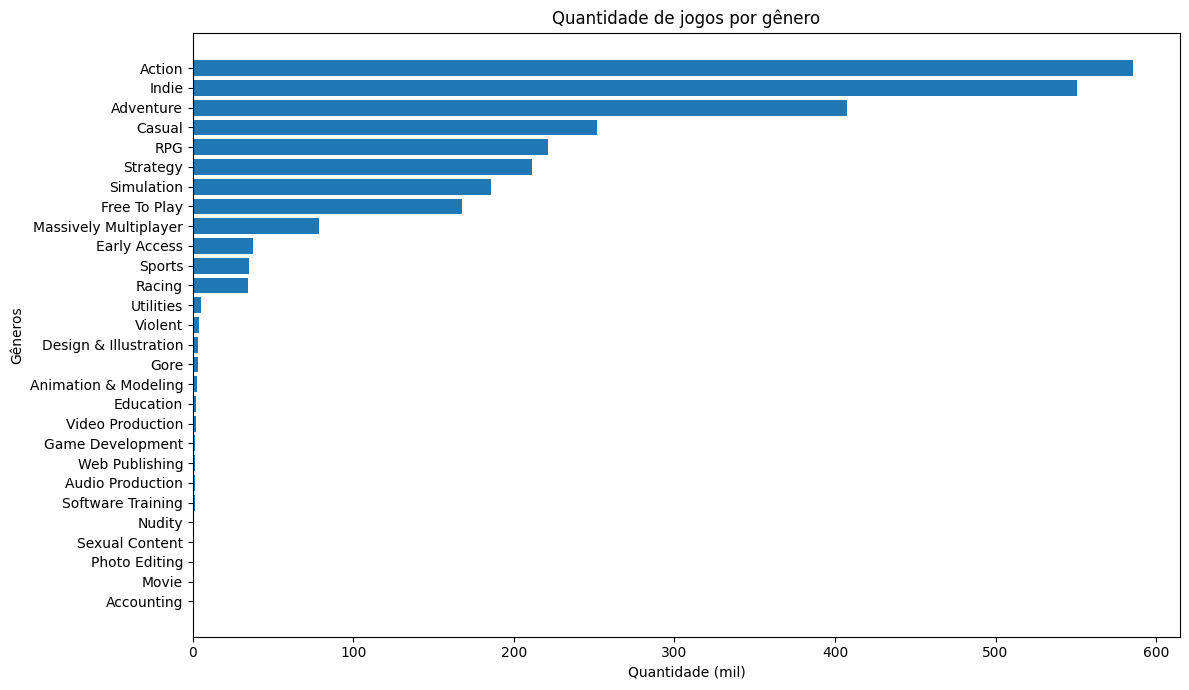

In [123]:
# Visualizando com gráfico de barras
fig, ax = plt.subplots(figsize=(12, 7))

plt.barh(contagem_generos[contagem_generos.columns[1:]].sum().sort_values(ascending=True).index, contagem_generos[contagem_generos.columns[1:]].sum().sort_values(ascending=True) / 1e3)

plt.ylabel('Gêneros')
plt.xlabel('Quantidade (mil)')
plt.title('Quantidade de jogos por gênero')

plt.tight_layout()
plt.show()

Agora podemos visualizar os gêneros favoritos dos usuários, por mais que a quantidade aparente estar errado, ela representa a quantidade total de jogos, podendo 2 ou mais usuários terem o mesmo jogo.

Concluindo a hipótese de se os jogadores tem algum genero favorito, sim eles tem, sendo os 3 com mais jogos action, indie e adventure.

###Os jogos mais vendidos são de uma mesma desenvolvedora?

Para que esta pergunta seja respondida é necessário realizar a contagem da ocorrência de um mesmo jogo na biblioteca dos jogadores e após isso analisar os primeiros 10 jogos e ver a ocorrência de desenvolvedores repetidos.

In [145]:
# Capturando os dados dos conjuntos players e games

desenvolvedores = players.copy()
desenvolvedores_tmp = games.copy()

In [146]:
# Realizando a exclusão das colunas que não urei utilizar

desenvolvedores = desenvolvedores.drop(columns=['created_since', 'country', 'achievement_library', 'achievements_count'])
desenvolvedores_tmp = desenvolvedores_tmp.drop(columns=['publishers', 'genres', 'supported_languages', 'achievements', 'usd'])

In [147]:
# Extendendo a coluna library

desenvolvedores['library'] = desenvolvedores['library'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

desenvolvedores = desenvolvedores.explode(column=['library'], ignore_index=True)

desenvolvedores = desenvolvedores.rename(columns={'library': 'gameid'})

In [148]:
# Anexando os dois conjuntos

desenvolvedores = desenvolvedores.merge(desenvolvedores_tmp, on='gameid', how='left')

desenvolvedores

,playerid,gameid,title,developers
0,76561198220441373,2100,Dark Messiah of Might & Magic,['Arkane Studios']
1,76561198220441373,2130,Dark Messiah of Might & Magic,['Arkane Studios']
2,76561198220441373,3830,Psychonauts,['Double Fine Productions']
3,76561198220441373,220240,Far Cry 3,"['Ubisoft Montreal, Massive Entertainment, and..."
4,76561198220441373,214510,LEGO® The Lord of the Rings™,"[""Traveller's Tales""]"
...,...,...,...,...
1150883,76561198138610183,252850,Streamline,['Proletariat Inc.']
1150884,76561198138610183,1172620,Sea of Thieves: 2024 Edition,['Rare Ltd']
1150885,76561198138610183,346110,ARK: Survival Evolved,"['Studio Wildcard', 'Instinct Games', 'Efecto ..."
1150886,76561198138610183,407530,ARK: The Survival Of The Fittest,"['Studio Wildcard', 'Instinct Games', 'Efecto ..."


In [155]:
# Realizando a contagem de jogos

contagem_desenvolvedores = desenvolvedores.groupby('gameid')['title'].value_counts().reset_index()

contagem_desenvolvedores = contagem_desenvolvedores.merge(desenvolvedores_tmp[['gameid', 'developers']], on='gameid', how='left')

contagem_desenvolvedores

,gameid,title,count,developers
0,10,Counter-Strike,1402,['Valve']
1,20,Team Fortress Classic,742,['Valve']
2,30,Day of Defeat,679,['Valve']
3,40,Deathmatch Classic,660,['Valve']
4,50,Half-Life: Opposing Force,772,['Gearbox Software']
...,...,...,...,...
31663,3302510,Liquidator 2: Welcome to Hell,1,['Parallax Arts Studio']
31664,3322710,Dragon Fishing,2,['Vantan Game Academy']
31665,3341420,They're Alive!,1,['Orion Games']
31666,3341450,Rat Hunter,2,['Secret Sign']


In [179]:
contagem_desenvolvedores['developers'] = contagem_desenvolvedores['developers'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

contagem_desenvolvedores['developers'].iloc[3][0]

'OVERKILL - a Starbreeze Studio.'

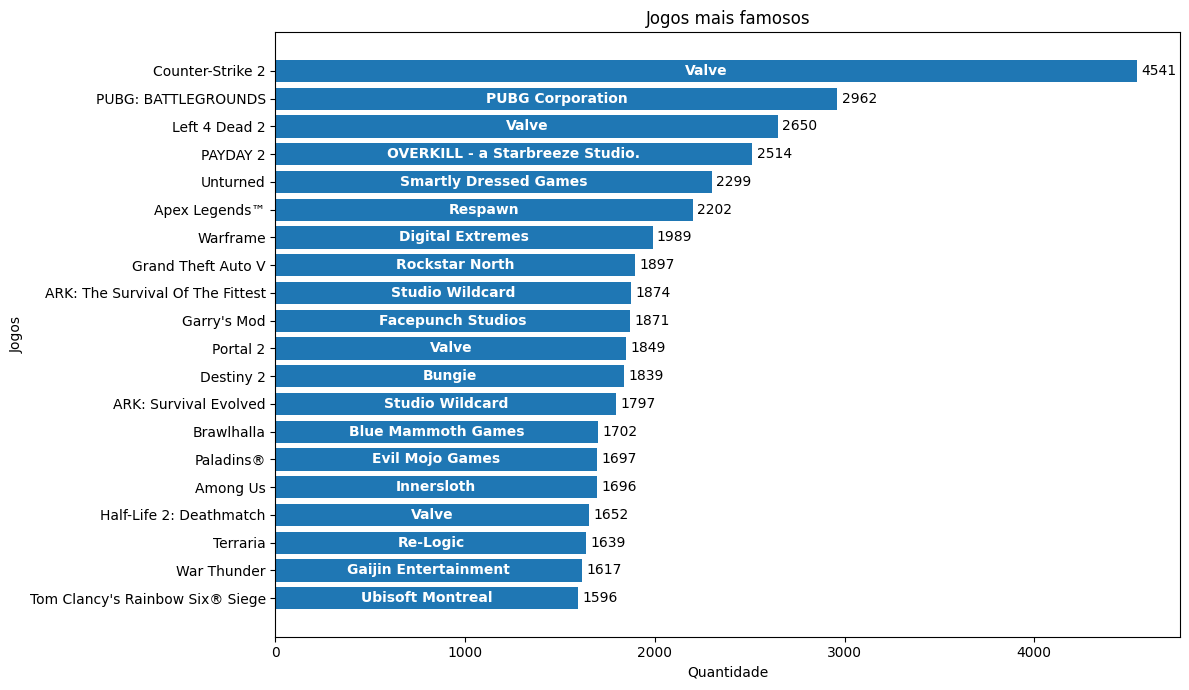

In [181]:
# Visualizando com barras qual os jogos mais famosos

contagem_desenvolvedores = contagem_desenvolvedores.sort_values(by='count', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(contagem_desenvolvedores['title'].head(20), contagem_desenvolvedores['count'].head(20))

ax.bar_label(bars, label_type='edge', fmt='%d', padding=3)

cont = 0
for bar in bars:
    largura = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    x = largura / 2

    ax.text(x, y, f'{contagem_desenvolvedores["developers"].iloc[cont][0]}', va='center', ha='center', color='white', fontweight='bold')
    cont += 1


plt.ylabel('Jogos')
plt.xlabel('Quantidade')
plt.title('Jogos mais famosos')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Visualizando o gráfico é possivel notar que nos primeiros 10 jogos no topo, há 2 ocorrências da desenvolvedora Valve, já com um olhar mais amplo com os 20 primeiros jogos há 4 ocorrências da valve. Por mais que pareça que ela influência o usuário na hora de adquirir o jogo, isso não ocorre muito.

# Conclusão

O DataSet Gaming Profile 2025 representou um grande desafio para captura de dados palpaveis e que representassem algum significado, com ele consegui responder as quatro perguntas de hipótese através do agrupamento de informações de 6 conjuntos diferentes. Pude verificar como é o comportamento dos jogadores dentro da plataforma Steam, descobri quais genêros os jogadores preferem, bem como o ritmo em que os jogos de suas bibliotecas são jogados.